# 📊 Zeitreihenprognose mit Prophet
## Demo: Rossmann Store Sales – Analyst-in-the-Loop

---

### 🧮 Die theoretische Basis: Die Prophet-Gleichung
Prophet basiert auf einem additiven (oder multiplikativen) Regressionsmodell. In der Grundform lautet die Formel:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

* **$g(t)$ (Trend):** Bildet nicht-periodische Veränderungen ab (z.B. langfristiges Wachstum).
* **$s(t)$ (Saisonalität):** Greift periodische Veränderungen auf (wöchentliche, jährliche Muster).
* **$h(t)$ (Holidays/Feiertage):** Modelliert unregelmäßige, punktuelle Events.
* **$\epsilon_t$ (Fehlerterm):** Das Rauschen, das unser Modell nicht erklären kann.

> 📌 Das ist die **Grundausstattung** von Prophet. Später – sobald wir externe, steuerbare Einflussgrößen (z.B. Promotionen) einbauen – erweitern wir diese Gleichung um einen zusätzlichen **Regressor-Term**.

**Unser Ziel heute:** Wir sehen uns anhand eines realen Datensatzes an, wie wir als Analysten gezielt in $h(t)$ eingreifen (und später einen Regressor ergänzen) können, um das Modell massiv zu verbessern. In der hands-on Demo verwenden wir einen synthetischen Datensatzes, der die wesentlichen Merkmale und die Verwendung von Prophet sehr deutlich macht.

---

### 🏪 Der Datensatz: Rossmann Drogeriemarkt
Wir nutzen historische Verkaufsdaten von Rossmann (Quelle: [Kaggle](https://www.kaggle.com/c/rossmann-store-sales)).
* 1.017.209 tägliche Umsatzbeobachtungen für **1.115 Filialen** in Deutschland
* Zeitraum: 01.01.2013 – 31.07.2015

### 🗺️ Zwei Filialen – zwei verschiedene Welten
Das Problem an generischen Modellen: Sie übersehen lokale Besonderheiten. Schauen wir uns zwei Filialen an Feiertagen an:

| Filiale | Typ | Ostersamstag | Ostermontag | 1. Mai |
|---|---|---|---|---|
| **530** | Ferienort-Filiale | ✅ offen, **2.6x Umsatz** | ✅ offen | ❌ geschlossen |
| **262** | Ferienort-Filiale | – | – | ✅ offen, **33.982€ Ø** |
| **16** | Normale Stadtfiliale | – | – | ❌ geschlossen, 0€ |

> **Weiterführende Ressource:** [Prophet Dokumentation](https://facebook.github.io/prophet/)

---
### 🎛️ Die wichtigsten Prophet-Stellschrauben

Jeder Term der Gleichung lässt sich über Parameter steuern. Die wichtigsten im Überblick (Default-Werte in Klammern):

| Gleichungs-Term | Parameter / Methode | Wirkung |
|---|---|---|
| **$g(t)$ – Trend** | `growth='linear'` / `'logistic'` / `'flat'` | Form des Trends (`logistic` braucht zusätzlich `cap`) |
| | `changepoint_prior_scale` (0.05) | Flexibilität des Trends – höher = mehr/stärkere Knicke |
| | `n_changepoints` (25), `changepoint_range` (0.8) | Anzahl & Lage möglicher Trendwechsel |
| **$s(t)$ – Saisonalität** | `yearly_seasonality`, `weekly_seasonality`, `daily_seasonality` | `True` / `False` / `'auto'` oder Fourier-Ordnung (int) |
| | `seasonality_mode='additive'` / `'multiplicative'` | Saison wird addiert oder skaliert prozentual |
| | `seasonality_prior_scale` (10) | Stärke/Regularisierung der Saison |
| | `add_seasonality(name, period, fourier_order)` | Eigene Saison definieren (z.B. monatlich) |
| **$h(t)$ – Holidays** | `holidays=DataFrame` | Feiertags-/Event-Kalender |
| | `lower_window`, `upper_window` | Effekt über mehrere Tage davor/danach strecken |
| | `holidays_prior_scale` (10) | Stärke der Feiertags-Effekte |
| | `add_country_holidays('DE')` | Eingebaute Länder-Feiertage |
| **$\beta X(t)$ – Regressor** | `add_regressor(name, mode, prior_scale)` | Externe Variable einbinden *(führen wir in Teil 5 ein)* |
| **Unsicherheit** | `interval_width` (0.80) | Breite des Konfidenzbands |
| | `mcmc_samples` (0) | `>0` = volle Bayes-Schätzung (genauere Intervalle, langsam) |

**Typischer Workflow:**
`m = Prophet(...)` → ggf. `m.add_regressor(...)` → `m.fit(df)` → `future = m.make_future_dataframe(...)` → `m.predict(future)` → `m.plot()` / `m.plot_components()`

> 💡 In dieser Demo fassen wir vor allem `holidays` ($h(t)$) und `add_regressor` ($\beta X(t)$) an – das sind die zentralen Hebel für **Analyst-in-the-Loop**.

## 📦 1. Installation & Imports

In [ ]:
!pip install prophet matplotlib seaborn scikit-learn --quiet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Hilfsfunktionen Metriken
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)) * 100

def print_metrics(y_true, y_pred, name):
    print(f'{name}:')
    print(f'  RMSE:  {rmse(y_true, y_pred):.0f} €')
    print(f'  RMSPE: {rmspe(y_true, y_pred):.1f}%')

print('✅ Alle Bibliotheken erfolgreich geladen!')

✅ Alle Bibliotheken erfolgreich geladen!


---
## 🔍 2. Explorative Datenanalyse (EDA)

In [5]:
train = pd.read_csv('../data/rossmann-store-sales/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/rossmann-store-sales/store.csv')

print('📁 train.csv:', train.shape)
train.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/rossmann-store-sales/train.csv'

In [4]:
print('📁 store.csv:', store.shape)
store.head()

NameError: name 'store' is not defined

### 2.1 Die Daten verstehen

Der Rossmann-Datensatz besteht aus **zwei** Dateien, die über die `Store`-ID verknüpft sind.

**`train.csv` – die eigentliche Zeitreihe (eine Zeile = eine Filiale an einem Tag):**

| Spalte | Bedeutung | Werte |
|---|---|---|
| `Store` | Filial-ID | 1 – 1115 |
| `DayOfWeek` | Wochentag | 1 = Mo … 7 = So |
| `Date` | Datum | 2013-01-01 bis 2015-07-31 |
| `Sales` | **Zielgröße: Tagesumsatz (€)** | 0 – ~40.000 |
| `Customers` | Anzahl Kunden am Tag | 0 – ~7.000 |
| `Open` | War die Filiale geöffnet? | 0 = nein, 1 = ja |
| `Promo` | Lief eine Tages-Promotion? | 0 / 1 |
| `StateHoliday` | Art des Feiertags | **0** = kein, **a** = gesetzl. Feiertag, **b** = Ostern, **c** = Weihnachten |
| `SchoolHoliday` | Schulferien? | 0 / 1 |

**`store.csv` – Stammdaten je Filiale (eine Zeile = eine Filiale):**

| Spalte | Bedeutung |
|---|---|
| `StoreType`, `Assortment` | Filialtyp & Sortimentsbreite (a/b/c/d) |
| `CompetitionDistance` | Entfernung zum nächsten Wettbewerber (in Metern) |
| `Promo2`, `PromoInterval` | Teilnahme an einer fortlaufenden Dauer-Promotion |

**Worauf wir bei der Modellierung achten müssen:**
- **Geschlossene Tage** (`Open=0`) haben `Sales=0`. Diese Nullen würden Trend und Saisonalität verzerren → wir filtern in allen Modellen konsequent auf `Open==1`.
- **`StateHoliday` ist die Mehrheits-Sicht.** Ob eine *einzelne* Filiale wirklich geöffnet ist, steht in `Open` – nicht in `StateHoliday`. Daher die scheinbaren Widersprüche (Ostermontag = `b`, aber Filiale 530 hat offen).
- **`Customers`** korreliert stark mit `Sales`, ist aber für die **Zukunft nicht bekannt** → als Regressor ungeeignet (man müsste es selbst prognostizieren). `Promo` dagegen ist planbar und auch für den Testzeitraum bekannt → der ideale Regressor (mehr dazu in Teil 5).

> **🎯 Wichtige Erkenntnis:** Der Datensatz kodiert Feiertage aus Sicht der **Mehrheit der Filialen**.
> Insel- und Ferienort-Filialen verhalten sich an Feiertagen komplett anders – das ist im Datensatz **nicht** direkt sichtbar!
> Genau hier ist Analyst-in-the-Loop unverzichtbar.

In [3]:
# Datensatz auf einen Blick
print('train.csv:', train.shape, ' | store.csv:', store.shape)
print('Zeitraum :', train['Date'].min().date(), '–', train['Date'].max().date())
print('Filialen :', train['Store'].nunique())
print()

print('StateHoliday-Verteilung (Zeilenanteil):')
print((train['StateHoliday'].astype(str).value_counts(normalize=True) * 100).round(2).astype(str) + ' %')
print()

print(f"Anteil geschlossener Tage (Open=0): {(train['Open'] == 0).mean() * 100:.1f}%")
print(f"Anteil Tage mit Sales == 0       : {(train['Sales'] == 0).mean() * 100:.1f}%")
print(f"Anteil Promo-Tage (Promo=1)      : {(train['Promo'] == 1).mean() * 100:.1f}%")
print()

print('Kennzahlen für geöffnete Tage (Open==1):')
print(train.loc[train['Open'] == 1, ['Sales', 'Customers']].describe().round(0))

NameError: name 'train' is not defined

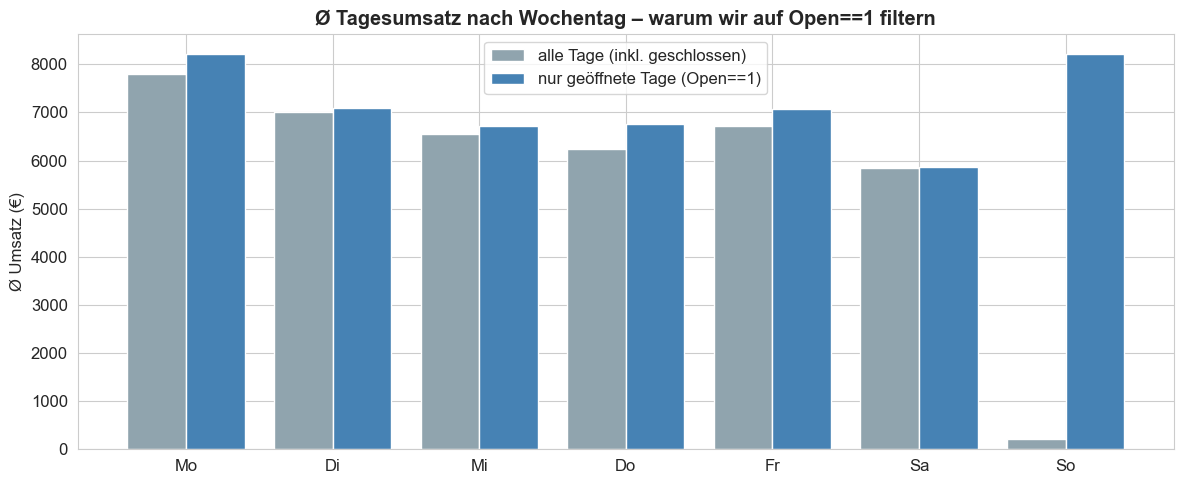

Anteil geöffneter Filialen je Wochentag:
  Mo:  95.0%
  Di:  98.8%
  Mi:  97.4%
  Do:  92.3%
  Fr:  95.1%
  Sa:  99.5%
  So:   2.5%

-> Sonntag bricht in der GRAUEN Reihe fast auf 0 ein – nicht wegen geringer Nachfrage,
   sondern weil fast alle Filialen geschlossen sind (siehe Öffnungsquote).
   Die BLAUE Reihe (nur offene Tage) zeigt die echte Nachfrage, die die Wochensaison lernen soll.


In [8]:
# Ø Umsatz nach Wochentag: warum wir Open==1 filtern
wochentage = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
order = [1, 2, 3, 4, 5, 6, 7]   # DayOfWeek: 1=Mo ... 7=So

mean_all  = train.groupby('DayOfWeek')['Sales'].mean().reindex(order)
mean_open = train[train['Open'] == 1].groupby('DayOfWeek')['Sales'].mean().reindex(order)

x = np.arange(7)
w = 0.4
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, mean_all.values,  w, label='alle Tage (inkl. geschlossen)', color='#90A4AE')
ax.bar(x + w/2, mean_open.values, w, label='nur geöffnete Tage (Open==1)', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(wochentage)
ax.set_title('Ø Tagesumsatz nach Wochentag – warum wir auf Open==1 filtern', fontweight='bold')
ax.set_ylabel('Ø Umsatz (€)')
ax.legend()
plt.tight_layout()
plt.show()

# Öffnungsquote je Wochentag
open_rate = train.groupby('DayOfWeek')['Open'].mean().reindex(order)
print('Anteil geöffneter Filialen je Wochentag:')
for d, wt in zip(order, wochentage):
    print(f'  {wt}: {open_rate[d] * 100:5.1f}%')
print()
print('-> Sonntag bricht in der GRAUEN Reihe fast auf 0 ein – nicht wegen geringer Nachfrage,')
print('   sondern weil fast alle Filialen geschlossen sind (siehe Öffnungsquote).')
print('   Die BLAUE Reihe (nur offene Tage) zeigt die echte Nachfrage, die die Wochensaison lernen soll.')

### 2.2 Warum wir geschlossene Tage (`Open==0`) herausfiltern

Die Grafik oben zeigt es: Sonntags bricht der Umsatz in der grauen Reihe fast auf 0 ein – aber **nicht** wegen geringer Nachfrage, sondern weil fast alle Filialen geschlossen sind. Eine 0 an einem geschlossenen Tag ist also kein Nachfragewert, sondern ein deterministischer „Laden zu"-Schalter. Lässt man diese Nullen im Training, müssen Trend, Saison und Feiertage sie miterklären – und werden dadurch verzerrt:

- **Wochensaison $s(t)$:** Prophet lernt aus den vielen Sonntags-Nullen einen riesigen Sonntags-Abschlag. Das modelliert aber den *Öffnungsplan*, nicht das *Kaufverhalten*. Für eine Ferienort-Filiale, die sonntags oder am Ostermontag **offen** hat, sagt so ein Modell fälschlich ≈ 0 voraus – also genau die Fälle, die uns interessieren.
- **Trend/Niveau $g(t)$:** Viele Nullen drücken das mittlere Niveau nach unten. Schwankt der Anteil geschlossener Tage über die Zeit, verbiegt das den geschätzten Trend, obwohl sich die echte Nachfrage nicht geändert hat.
- **Feiertage $h(t)$:** Schließt eine Filiale am Feiertag, lernt Prophet „Feiertag = Umsatz 0". Dieser Schließ-Effekt überlagert dann den eigentlichen Nachfrage-Effekt, den wir mit `holidays` ja gerade sauber isolieren wollen.

**Der entscheidende Punkt:** Ob eine Filiale öffnet, **wissen wir vorab** – `Open` ist auch für die Zukunft planbar. Das muss kein Modell statistisch „vorhersagen". Sauberer ist daher: nur die **offenen** Tage modellieren (der reine Nachfrageprozess) und geschlossene Tage hinterher per `Open`-Flag auf 0 setzen. Deshalb filtern wir in allen Modellen konsequent auf `Open == 1`.

> 🔧 Technisch ließe sich das auch mit `seasonality_mode='multiplicative'` oder einem eigenen Regressor abfedern – fürs Filtern haben wir den klarsten und gängigsten Weg gewählt.

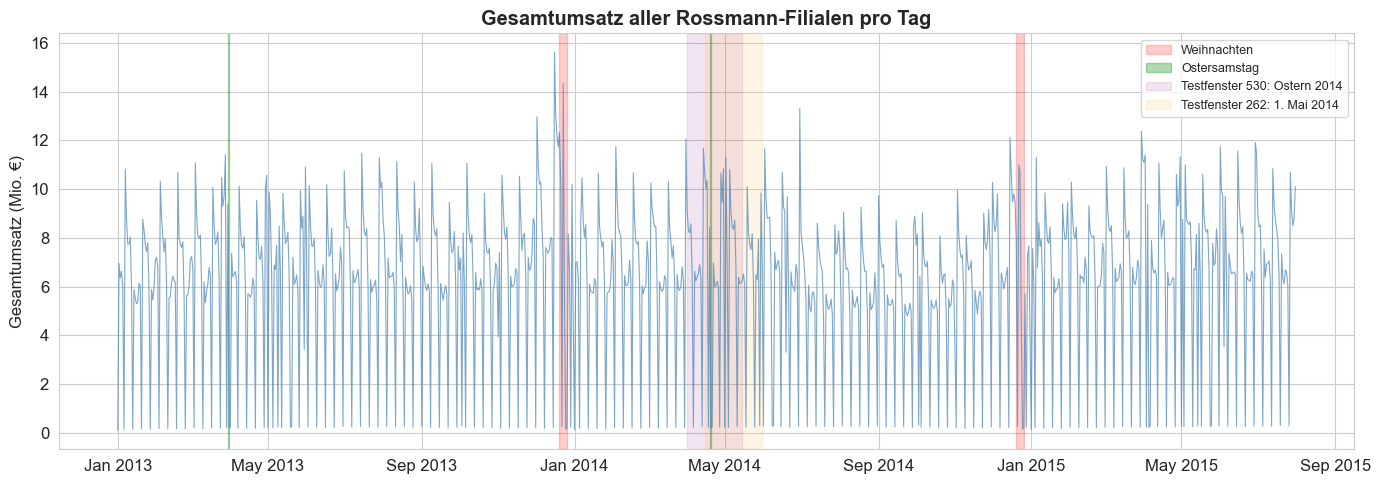

In [9]:
# Gesamtumsatz über Zeit
daily_total = train[train['Open'] == 1].groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total['Date'], daily_total['Sales'] / 1e6, color='steelblue', alpha=0.7, linewidth=0.8)

for year in [2013, 2014]:
    ax.axvspan(pd.Timestamp(f'{year}-12-20'), pd.Timestamp(f'{year}-12-26'),
               alpha=0.2, color='red', label='Weihnachten' if year == 2013 else '')
for ostern_d in ['2013-03-30', '2014-04-19']:
    ax.axvspan(pd.Timestamp(ostern_d), pd.Timestamp(ostern_d) + pd.Timedelta(days=1),
               alpha=0.3, color='green', label='Ostersamstag' if ostern_d == '2013-03-30' else '')

# Testfenster Filiale 530 (Ostern)
ax.axvspan(pd.Timestamp('2014-04-01'), pd.Timestamp('2014-05-15'),
           alpha=0.1, color='purple', label='Testfenster 530: Ostern 2014')
# Testfenster Filiale 262 (1. Mai)
ax.axvspan(pd.Timestamp('2014-04-15'), pd.Timestamp('2014-05-31'),
           alpha=0.1, color='orange', label='Testfenster 262: 1. Mai 2014')

ax.set_title('Gesamtumsatz aller Rossmann-Filialen pro Tag', fontweight='bold')
ax.set_ylabel('Gesamtumsatz (Mio. €)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

---
## 🎯 3. Analyst-in-the-Loop: Wenn derselbe Feiertag das Gegenteil bedeutet

Der rote Faden der folgenden Beispiele: **Derselbe Kalendertag kann je nach Filialtyp einen völlig entgegengesetzten Effekt haben.** Der Datensatz kodiert Feiertage nur aus Sicht der *Mehrheit* der Filialen – lokale Besonderheiten (Ferienorte, Inseln) bleiben unsichtbar. Genau hier bringt der Analyst sein Wissen über `holidays` ein.

- **3.1 Ostern (Filiale 530):** Ostersamstag-Boom und geöffneter Ostermontag – im Datensatz nicht erkennbar.
- **3.4 Der 1. Mai (262 vs. 16):** Derselbe Feiertag, gegensätzliche Wirkung – Ferienort boomt, Stadtfiliale geschlossen.
- Dazwischen ein **Realitäts-Check (3.3):** Was passiert, wenn wir einfach alle Filialen zusammen prognostizieren?

> 💡 In allen Fällen vergleichen wir ein **Baseline-Modell** (nur das, was der Datensatz hergibt) mit einem **Experten-Modell** (Baseline + Analyst-Wissen).

---
### 🥚 3.1 Ostern an der Ferienort-Filiale 530

### Das Problem

Filiale 530 (vermutlich Ferienort/Insel) verhält sich an Ostern **komplett anders** als der Datensatz suggeriert:

| Tag | StateHoliday | Normalfiliale | Filiale 530 |
|---|---|---|---|
| Karfreitag | `b` | ❌ geschlossen | ❌ geschlossen |
| **Ostersamstag** | **`0`** ❗ | normal ~5.500€ | **~11.000€ (2.6x!)** |
| Ostersonntag | `0` | geschlossen | geschlossen |
| **Ostermontag** | **`b`** ❗ | ❌ geschlossen | **✅ offen ~5.300€** |

**Zwei unsichtbare Effekte:**
1. Ostersamstag: `StateHoliday='0'` aber 2.6x Umsatz – Touristen kaufen vor dem langen Wochenende
2. Ostermontag: `StateHoliday='b'` aber offen – Prophet würde Schließung vorhersagen

Filiale 530:
Training: 2013-01-01 – 2014-03-31 (438 Tage)
Test:     2014-04-01 – 2014-05-15 (43 Tage)


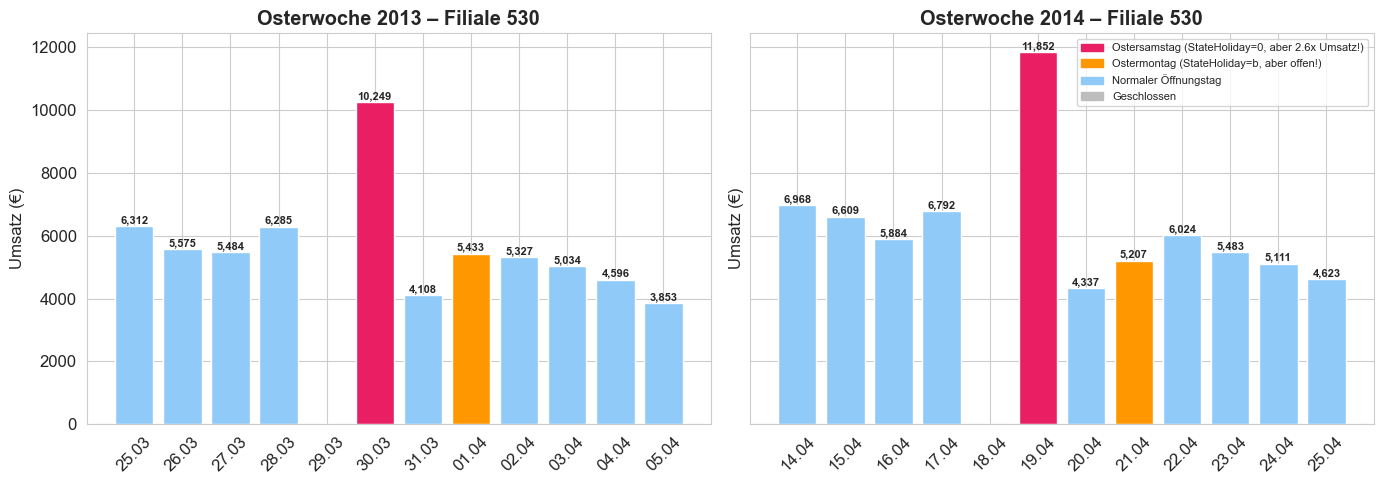

🔑 Beide Effekte sind im Datensatz UNSICHTBAR – reines Analyst-Wissen!


In [10]:
STORE_530 = 530
CUTOFF_530   = '2014-04-01'
TEST_END_530 = '2014-05-15'

df_530 = train[train['Store'] == STORE_530].copy().sort_values('Date').reset_index(drop=True)

df_train_530 = df_530[(df_530['Date'] < CUTOFF_530) & (df_530['Open'] == 1)]
df_test_530  = df_530[(df_530['Date'] >= CUTOFF_530) & (df_530['Date'] <= TEST_END_530) & (df_530['Open'] == 1)]

print(f'Filiale {STORE_530}:')
print(f'Training: {df_train_530["Date"].min().date()} – {df_train_530["Date"].max().date()} ({len(df_train_530)} Tage)')
print(f'Test:     {df_test_530["Date"].min().date()} – {df_test_530["Date"].max().date()} ({len(df_test_530)} Tage)')

# Osterwochen visualisieren
oster_530 = df_530[
    (df_530['Date'] >= '2013-03-25') & (df_530['Date'] <= '2013-04-05') |
    (df_530['Date'] >= '2014-04-14') & (df_530['Date'] <= '2014-04-25')
].copy()
oster_530['Jahr'] = oster_530['Date'].dt.year
oster_530['Tag']  = oster_530['Date'].dt.strftime('%d.%m')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (jahr, gruppe) in zip(axes, oster_530.groupby('Jahr')):
    bars = ax.bar(gruppe['Tag'], gruppe['Sales'], color=[
        '#E91E63' if (row['Open'] == 1 and row['Date'].dayofweek == 5 and row['StateHoliday'] == '0')
        else '#FF9800' if (row['Open'] == 1 and row['StateHoliday'] == 'b')
        else '#90CAF9' if row['Open'] == 1
        else '#BDBDBD'
        for _, row in gruppe.iterrows()
    ])
    ax.set_title(f'Osterwoche {jahr} – Filiale {STORE_530}', fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.tick_params(axis='x', rotation=45)
    for bar, (_, row) in zip(bars, gruppe.iterrows()):
        if row['Sales'] > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                    f"{row['Sales']:,.0f}", ha='center', fontsize=8, fontweight='bold')

# Legende
from matplotlib.patches import Patch
legend = [
    Patch(color='#E91E63', label='Ostersamstag (StateHoliday=0, aber 2.6x Umsatz!)'),
    Patch(color='#FF9800', label='Ostermontag (StateHoliday=b, aber offen!)'),
    Patch(color='#90CAF9', label='Normaler Öffnungstag'),
    Patch(color='#BDBDBD', label='Geschlossen'),
]
axes[1].legend(handles=legend, loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
print('🔑 Beide Effekte sind im Datensatz UNSICHTBAR – reines Analyst-Wissen!')

In [11]:
# Feiertage definieren
feiertage_a = train[train['StateHoliday'] == 'a'][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
feiertage_a['holiday'] = 'gesetzlicher_feiertag'

weihnachten = train[train['StateHoliday'] == 'c'][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
weihnachten['holiday'] = 'weihnachten'

schulferien = train[train['SchoolHoliday'] == 1][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
schulferien['holiday'] = 'schulferien'

# Ostern (StateHoliday='b') – aber Ostermontag bei Filiale 530 ist offen!
# Wir behalten 'b' für Karfreitag (geschlossen), Ostermontag behandeln wir separat
karfreitag = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-29', '2014-04-18']),
    'holiday': 'karfreitag'
})

# 🎯 ANALYST-WISSEN 1: Ostersamstag – StateHoliday='0' aber 2.6x Umsatz!
ostersamstag = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-30', '2014-04-19']),
    'holiday': 'ostersamstag'
})

# 🎯 ANALYST-WISSEN 2: Ostermontag – StateHoliday='b' aber Filiale 530 hat GEÖFFNET!
# Wir definieren ihn als eigenen positiven Effekt statt als Schließtag
ostermontag_insel = pd.DataFrame({
    'ds': pd.to_datetime(['2013-04-01', '2014-04-21']),
    'holiday': 'ostermontag_insel'
})

# Baseline Holidays (ohne Analyst-Wissen)
ostern_standard = train[train['StateHoliday'] == 'b'][['Date']].drop_duplicates().rename(columns={'Date': 'ds'})
ostern_standard['holiday'] = 'ostern'
holidays_baseline = pd.concat([feiertage_a, ostern_standard, weihnachten, schulferien], ignore_index=True)

# Expert Holidays (mit Analyst-Wissen)
holidays_expert = pd.concat([
    feiertage_a, karfreitag, ostersamstag, ostermontag_insel, weihnachten, schulferien
], ignore_index=True)

print('Holidays Baseline:', holidays_baseline['holiday'].value_counts().to_dict())
print('Holidays Expert: ', holidays_expert['holiday'].value_counts().to_dict())
print()
print('🎯 Expert-Modell kennt:')
print('   ostersamstag     → StateHoliday=0, aber Boom-Tag')
print('   ostermontag_insel → StateHoliday=b, aber geöffnet mit positivem Effekt')

Holidays Baseline: {'schulferien': 478, 'gesetzlicher_feiertag': 27, 'ostern': 6, 'weihnachten': 4}
Holidays Expert:  {'schulferien': 478, 'gesetzlicher_feiertag': 27, 'weihnachten': 4, 'karfreitag': 2, 'ostermontag_insel': 2, 'ostersamstag': 2}

🎯 Expert-Modell kennt:
   ostersamstag     → StateHoliday=0, aber Boom-Tag
   ostermontag_insel → StateHoliday=b, aber geöffnet mit positivem Effekt


In [12]:
# Prophet Format
prophet_train_530 = df_train_530[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
prophet_test_530  = df_test_530[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

# Baseline
print('Trainiere Baseline...')
m_base_530 = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_base_530.fit(prophet_train_530)
fc_base_530 = m_base_530.predict(prophet_test_530[['ds']])

# Expert
print('Trainiere Expert...')
m_expert_530 = Prophet(holidays=holidays_expert, yearly_seasonality=True,
                       weekly_seasonality=True, interval_width=0.80)
m_expert_530.fit(prophet_train_530)
fc_expert_530 = m_expert_530.predict(prophet_test_530[['ds']])

print('✅ Beide Modelle trainiert!')

21:23:14 - cmdstanpy - INFO - Chain [1] start processing


Trainiere Baseline...


21:23:14 - cmdstanpy - INFO - Chain [1] done processing
21:23:15 - cmdstanpy - INFO - Chain [1] start processing
21:23:15 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Expert...
✅ Beide Modelle trainiert!


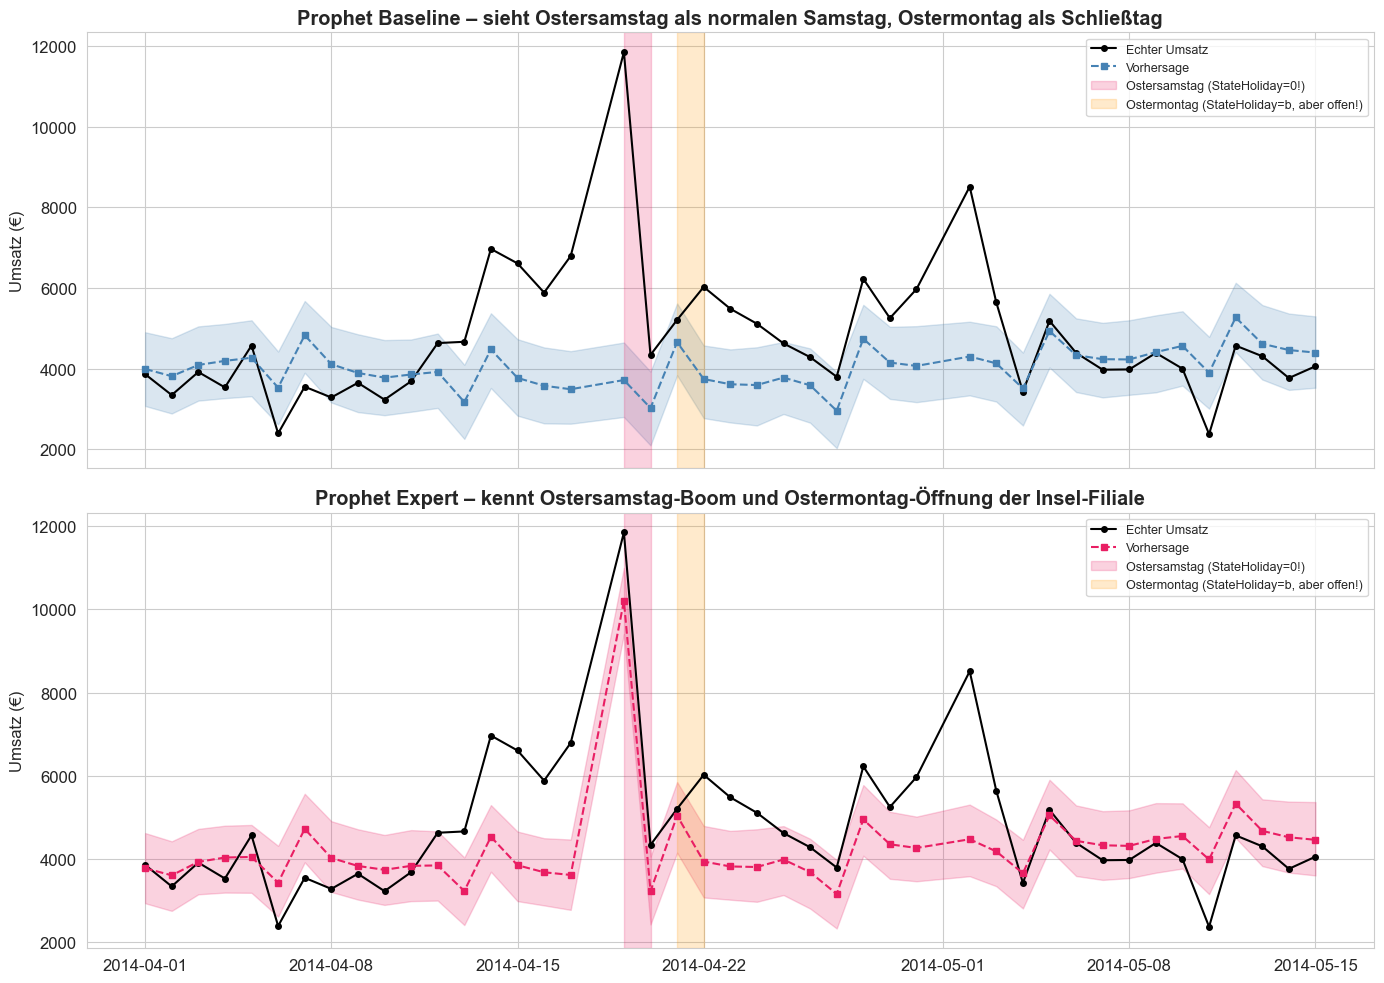

RMSPE Baseline: 28.2%
RMSPE Expert:   24.9%
Verbesserung:   3.3 Prozentpunkte


In [9]:
# Vergleichsplot Baseline vs. Expert – Filiale 530
y_true_530    = prophet_test_530['y'].values
test_dates_530 = prophet_test_530['ds'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, fc, title, color in zip(
    axes,
    [fc_base_530, fc_expert_530],
    ['Prophet Baseline – sieht Ostersamstag als normalen Samstag, Ostermontag als Schließtag',
     'Prophet Expert – kennt Ostersamstag-Boom und Ostermontag-Öffnung der Insel-Filiale'],
    ['steelblue', '#E91E63']
):
    ax.plot(test_dates_530, y_true_530, 'o-', color='black', markersize=4,
            label='Echter Umsatz', linewidth=1.5)
    ax.plot(fc['ds'], fc['yhat'], 's--', color=color, markersize=4,
            label='Vorhersage', linewidth=1.5)
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.2, color=color)
    ax.axvspan(pd.Timestamp('2014-04-19'), pd.Timestamp('2014-04-20'),
               alpha=0.2, color='#E91E63', label='Ostersamstag (StateHoliday=0!)')
    ax.axvspan(pd.Timestamp('2014-04-21'), pd.Timestamp('2014-04-22'),
               alpha=0.2, color='#FF9800', label='Ostermontag (StateHoliday=b, aber offen!)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# RMSPE direkt unter dem Plot
rmspe_base_530   = rmspe(y_true_530, fc_base_530['yhat'].values)
rmspe_expert_530 = rmspe(y_true_530, fc_expert_530['yhat'].values)
print(f'RMSPE Baseline: {rmspe_base_530:.1f}%')
print(f'RMSPE Expert:   {rmspe_expert_530:.1f}%')
print(f'Verbesserung:   {rmspe_base_530 - rmspe_expert_530:.1f} Prozentpunkte')

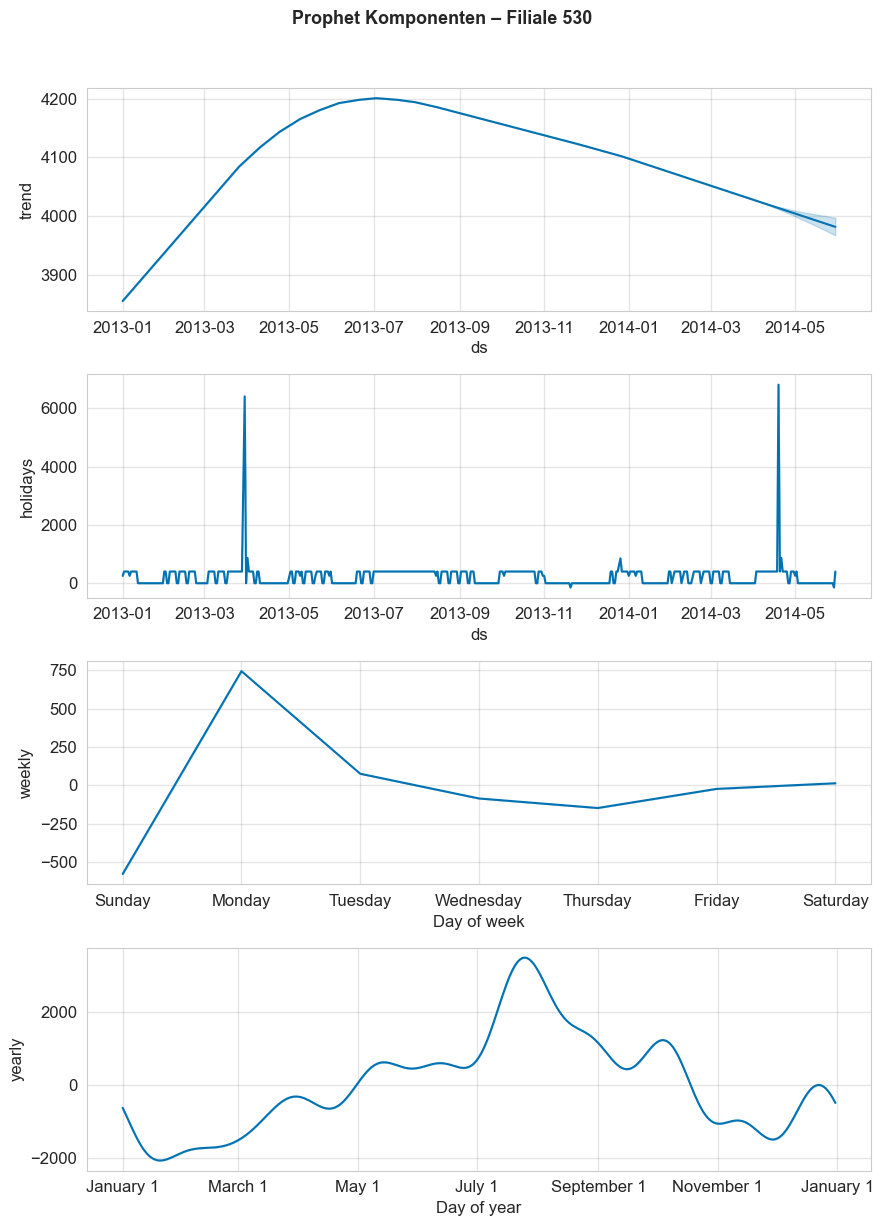

💡 Im holidays-Plot: ostersamstag zeigt positiven Effekt, ostermontag_insel ebenfalls!


In [10]:
# Komponenten-Plot – was hat Prophet gelernt?
future_530 = m_expert_530.make_future_dataframe(periods=60)
fc_full_530 = m_expert_530.predict(future_530)
fig = m_expert_530.plot_components(fc_full_530)
fig.suptitle(f'Prophet Komponenten – Filiale {STORE_530}', fontweight='bold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print('💡 Im holidays-Plot: ostersamstag zeigt positiven Effekt, ostermontag_insel ebenfalls!')

---
### 🪜 3.2 Schrittweise Verbesserung (Filiale 530)

Bisher haben wir Baseline und Expert direkt verglichen. Jetzt zeigen wir **wie** sich die Prognose Schritt für Schritt verbessert – jeder Analyst-Eingriff einzeln sichtbar gemacht.

| Stufe | Was kommt dazu | Idee |
|---|---|---|
| **0 – Baseline** | nur Standard-Feiertage (StateHoliday) | Was der Datensatz hergibt |
| **1 – Einzeltage** | + Ostersamstag, Ostermontag-Insel, Karfreitag, Tag-nach-1.Mai | Unsichtbare Tage explizit benennen |
| **2 – lower_window** | + Karwochen-Vorlauf (`lower_window=-5`) | Effekt über mehrere Tage strecken |

Die Karwoche zeigt in beiden Jahren erhöhten Umsatz (2013: 1.29x, 2014: 1.46x über Normal) – die Leute decken sich vor dem langen Osterwochenende ein. Mit `lower_window` lernt Prophet diesen Vorlauf, nicht nur den Samstags-Peak.

In [11]:
# Tag nach dem 1. Mai – Nachhol-/Brückentag-Effekt (Filiale 530 ist am 1. Mai geschlossen)
#   2013: 02.05. = Do, 6.275€ | 2014: 02.05. = Fr (Brückentag!), 8.513€
tag_nach_mai = pd.DataFrame({
    'ds': pd.to_datetime(['2013-05-02', '2014-05-02']),
    'holiday': 'tag_nach_1mai'
})

# === STUFE 1: Alle Sondertage als EINZELNE Tage (lower_window=0) ===
ostersamstag_einzeln = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-30', '2014-04-19']),
    'holiday': 'ostersamstag'
})
holidays_stufe1 = pd.concat([
    feiertage_a, karfreitag, ostersamstag_einzeln, ostermontag_insel,
    tag_nach_mai, weihnachten, schulferien
], ignore_index=True)

# === STUFE 2: Ostersamstag mit lower_window=-5 (ganze Karwoche) ===
ostersamstag_fenster = pd.DataFrame({
    'ds': pd.to_datetime(['2013-03-30', '2014-04-19']),
    'holiday': 'ostersamstag',
    'lower_window': -5,   # Mo–Fr der Karwoche
    'upper_window': 0
})
holidays_stufe2 = pd.concat([
    feiertage_a, karfreitag, ostersamstag_fenster, ostermontag_insel,
    tag_nach_mai, weihnachten, schulferien
], ignore_index=True)

print('Stufe 0 (Baseline):', holidays_baseline['holiday'].nunique(), 'Holiday-Typen')
print('Stufe 1 (Einzeltage):', holidays_stufe1['holiday'].nunique(), 'Holiday-Typen')
print('Stufe 2 (+lower_window): identische Typen, aber Ostersamstag deckt -5 Tage ab')

Stufe 0 (Baseline): 4 Holiday-Typen
Stufe 1 (Einzeltage): 7 Holiday-Typen
Stufe 2 (+lower_window): identische Typen, aber Ostersamstag deckt -5 Tage ab


In [12]:
# Drei Modelle trainieren
def fit_predict(holidays):
    m = Prophet(holidays=holidays, yearly_seasonality=True,
                weekly_seasonality=True, interval_width=0.80)
    m.fit(prophet_train_530)
    return m.predict(prophet_test_530[['ds']])

print('Trainiere 3 Stufen...')
fc_stufe0 = fit_predict(holidays_baseline)   # = Baseline von oben
fc_stufe1 = fit_predict(holidays_stufe1)
fc_stufe2 = fit_predict(holidays_stufe2)
print('✅ Alle 3 Stufen fertig!')

21:03:55 - cmdstanpy - INFO - Chain [1] start processing
21:03:55 - cmdstanpy - INFO - Chain [1] done processing


Trainiere 3 Stufen...


21:03:55 - cmdstanpy - INFO - Chain [1] start processing
21:03:55 - cmdstanpy - INFO - Chain [1] done processing
21:03:55 - cmdstanpy - INFO - Chain [1] start processing
21:03:55 - cmdstanpy - INFO - Chain [1] done processing


✅ Alle 3 Stufen fertig!


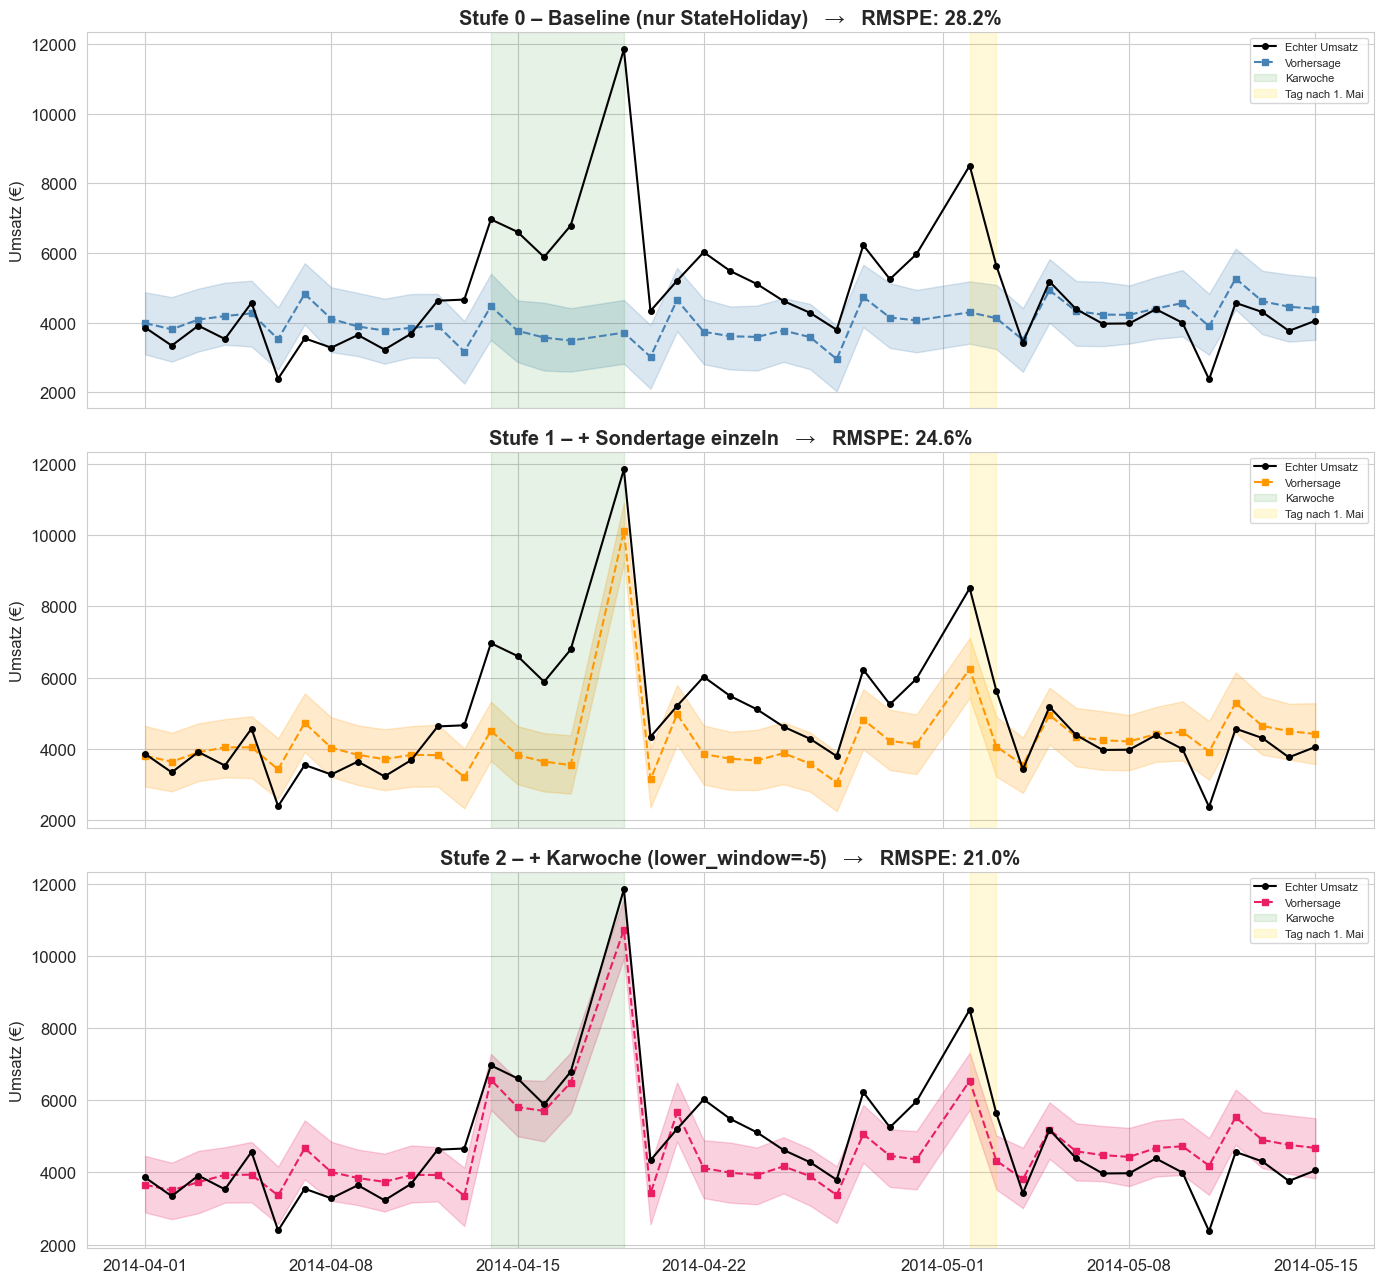

Schrittweise Verbesserung Filiale 530:
  Stufe 0 – Baseline (nur StateHoliday)         RMSPE: 28.2%
  Stufe 1 – + Sondertage einzeln                RMSPE: 24.6%
  Stufe 2 – + Karwoche (lower_window=-5)        RMSPE: 21.0%

🪜 Jeder Analyst-Schritt senkt den Fehler – das ist Analyst-in-the-Loop in Aktion!


In [13]:
# 3 Subplots untereinander + RMSPE je Stufe
stufen = [
    (fc_stufe0, 'Stufe 0 – Baseline (nur StateHoliday)', 'steelblue'),
    (fc_stufe1, 'Stufe 1 – + Sondertage einzeln', '#FF9800'),
    (fc_stufe2, 'Stufe 2 – + Karwoche (lower_window=-5)', '#E91E63'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

for ax, (fc, title, color) in zip(axes, stufen):
    ax.plot(test_dates_530, y_true_530, 'o-', color='black', markersize=4,
            label='Echter Umsatz', linewidth=1.5, zorder=5)
    ax.plot(fc['ds'], fc['yhat'], 's--', color=color, markersize=4,
            label='Vorhersage', linewidth=1.5)
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.2, color=color)
    # Karwoche + Ostersamstag markieren
    ax.axvspan(pd.Timestamp('2014-04-14'), pd.Timestamp('2014-04-19'),
               alpha=0.1, color='green', label='Karwoche')
    ax.axvspan(pd.Timestamp('2014-05-02'), pd.Timestamp('2014-05-03'),
               alpha=0.15, color='gold', label='Tag nach 1. Mai')
    rmspe_val = rmspe(y_true_530, fc['yhat'].values)
    ax.set_title(f'{title}   →   RMSPE: {rmspe_val:.1f}%', fontweight='bold')
    ax.set_ylabel('Umsatz (€)')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print('Schrittweise Verbesserung Filiale 530:')
for fc, title, _ in stufen:
    print(f'  {title:45s} RMSPE: {rmspe(y_true_530, fc["yhat"].values):.1f}%')
print()
print('🪜 Jeder Analyst-Schritt senkt den Fehler – das ist Analyst-in-the-Loop in Aktion!')

---
### 🧮 3.3 Realitäts-Check: alle Filialen auf einmal

Bisher haben wir einzelne Filialen modelliert. Naheliegende Frage: *Warum nicht einfach den **Gesamtumsatz aller 1.115 Filialen** prognostizieren?* Wir machen exakt dieselbe Prognose wie im ersten Beispiel (Baseline-Prophet, Zoom auf Ostern 2014) – nur für die **Summe** aller geöffneten Filialen.

**Hypothese:** Das geht schief, weil sich die Filialen unterschiedlich verhalten – und besonders am **Ostermontag**:

- Im Datensatz ist der Ostermontag als `StateHoliday='b'` kodiert – genau wie der Karfreitag. Die Baseline wirft beide in **einen** generischen Oster-Effekt (`ostern`).
- In Wirklichkeit sind am Karfreitag fast alle Filialen geschlossen, am **Ostermontag** haben aber etliche Ferienort-Filialen **geöffnet**. Der Gesamtumsatz am Ostermontag ist daher deutlich höher, als ein gemittelter Oster-Effekt vermuten lässt.

Die Baseline **unterschätzt den Ostermontag** also systematisch. Anschließend **reparieren** wir das, indem wir Karfreitag und Ostermontag als **getrennte** Holidays modellieren.

In [14]:
# === Gesamtumsatz aller GEÖFFNETEN Filialen pro Tag ===
agg = (train[train['Open'] == 1]
       .groupby('Date')['Sales'].sum()
       .reset_index()
       .rename(columns={'Date': 'ds', 'Sales': 'y'}))

# Gleiches Test-Setup wie im ersten Beispiel (Filiale 530): Ostern 2014
CUTOFF_AGG, TEST_END_AGG = '2014-04-01', '2014-05-15'
agg_train = agg[agg['ds'] < CUTOFF_AGG]
agg_test  = agg[(agg['ds'] >= CUTOFF_AGG) & (agg['ds'] <= TEST_END_AGG)]
print(f'Aggregat: Training {len(agg_train)} Tage | Test {len(agg_test)} Tage '
      f'({agg_test["ds"].min().date()} – {agg_test["ds"].max().date()})')

# --- Modell 1: BASELINE – Ostern als EIN generischer Effekt (lumped 'b') ---
m_agg_base = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_agg_base.fit(agg_train)
fc_agg_base = m_agg_base.predict(agg_test[['ds']])

# --- Modell 2: FIX – Karfreitag und Ostermontag GETRENNT modellieren ---
karfreitag_alle  = pd.DataFrame({'ds': pd.to_datetime(['2013-03-29', '2014-04-18']),
                                 'holiday': 'karfreitag'})
ostermontag_alle = pd.DataFrame({'ds': pd.to_datetime(['2013-04-01', '2014-04-21']),
                                 'holiday': 'ostermontag'})
# generischen 'ostern'-Topf weglassen, die zwei Tage einzeln einbauen
holidays_agg_fix = pd.concat([feiertage_a, weihnachten, schulferien,
                              karfreitag_alle, ostermontag_alle], ignore_index=True)
m_agg_fix = Prophet(holidays=holidays_agg_fix, yearly_seasonality=True,
                    weekly_seasonality=True, interval_width=0.80)
m_agg_fix.fit(agg_train)
fc_agg_fix = m_agg_fix.predict(agg_test[['ds']])
print('✅ Aggregat-Modelle (Baseline + Fix) trainiert!')

21:04:14 - cmdstanpy - INFO - Chain [1] start processing
21:04:14 - cmdstanpy - INFO - Chain [1] done processing


Aggregat: Training 455 Tage | Test 45 Tage (2014-04-01 – 2014-05-15)


21:04:14 - cmdstanpy - INFO - Chain [1] start processing
21:04:14 - cmdstanpy - INFO - Chain [1] done processing


✅ Aggregat-Modelle (Baseline + Fix) trainiert!


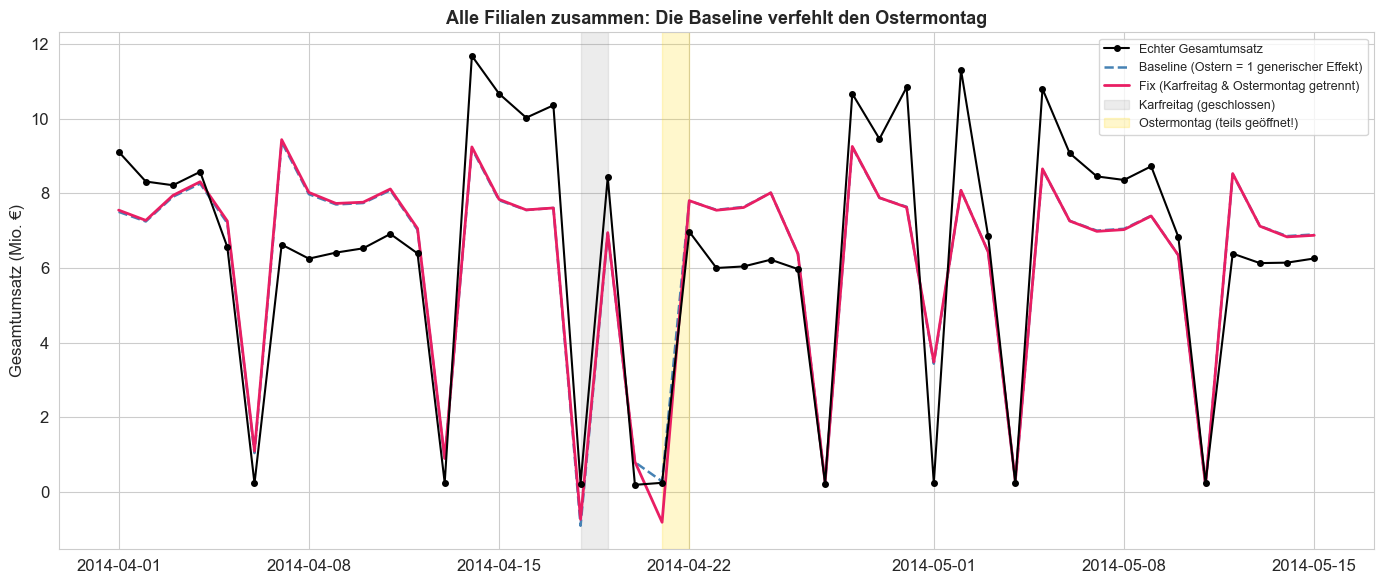

Ostermontag 21.04.2014 – echter Gesamtumsatz: 0.24 Mio €
  Baseline-Vorhersage: 0.28 Mio €  (Abweichung +16%)
  Fix-Vorhersage:      -0.82 Mio €  (Abweichung -439%)

RMSPE über den ganzen Testzeitraum:
  Baseline: 230.0%
  Fix:      239.5%


In [15]:
y_true_agg = agg_test['y'].values
dates_agg  = agg_test['ds'].values
OSTERMONTAG_2014 = pd.Timestamp('2014-04-21')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates_agg, y_true_agg / 1e6, 'o-', color='black', markersize=4,
        linewidth=1.5, label='Echter Gesamtumsatz', zorder=5)
ax.plot(fc_agg_base['ds'], fc_agg_base['yhat'] / 1e6, '--', color='steelblue',
        linewidth=1.8, label='Baseline (Ostern = 1 generischer Effekt)')
ax.plot(fc_agg_fix['ds'], fc_agg_fix['yhat'] / 1e6, '-', color='#E91E63',
        linewidth=2, label='Fix (Karfreitag & Ostermontag getrennt)')
ax.axvspan(pd.Timestamp('2014-04-18'), pd.Timestamp('2014-04-19'),
           alpha=0.15, color='gray', label='Karfreitag (geschlossen)')
ax.axvspan(OSTERMONTAG_2014, OSTERMONTAG_2014 + pd.Timedelta(days=1),
           alpha=0.2, color='gold', label='Ostermontag (teils geöffnet!)')
ax.set_title('Alle Filialen zusammen: Die Baseline verfehlt den Ostermontag',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Gesamtumsatz (Mio. €)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Fehler speziell am Ostermontag
mask = agg_test['ds'] == OSTERMONTAG_2014
if mask.any():
    actual_mo = agg_test.loc[mask, 'y'].values[0]
    base_mo   = fc_agg_base.loc[fc_agg_base['ds'] == OSTERMONTAG_2014, 'yhat'].values[0]
    fix_mo    = fc_agg_fix.loc[fc_agg_fix['ds'] == OSTERMONTAG_2014, 'yhat'].values[0]
    print(f'Ostermontag 21.04.2014 – echter Gesamtumsatz: {actual_mo/1e6:.2f} Mio €')
    print(f'  Baseline-Vorhersage: {base_mo/1e6:.2f} Mio €  '
          f'(Abweichung {(base_mo-actual_mo)/actual_mo*100:+.0f}%)')
    print(f'  Fix-Vorhersage:      {fix_mo/1e6:.2f} Mio €  '
          f'(Abweichung {(fix_mo-actual_mo)/actual_mo*100:+.0f}%)')
else:
    print('Hinweis: Ostermontag nicht im Aggregat enthalten – siehe Plot.')

print()
print(f'RMSPE über den ganzen Testzeitraum:')
print(f'  Baseline: {rmspe(y_true_agg, fc_agg_base["yhat"].values):.1f}%')
print(f'  Fix:      {rmspe(y_true_agg, fc_agg_fix["yhat"].values):.1f}%')

### 🔑 Was lernen wir daraus?

- Der **Gesamtumsatz** verdeckt, dass am Ostermontag manche Filialen geschlossen und andere im Boom sind. Die Baseline mittelt beides zu **einem** zu pessimistischen Oster-Effekt und unterschätzt den Tag.
- Schon das simple Auftrennen von Karfreitag und Ostermontag in **zwei** Holidays verbessert die Vorhersage **am Ostermontag** spürbar.
- **Aber:** Aggregat-Modelle stoßen schnell an Grenzen. Effekte, die sich *zwischen* Filialen gegenseitig aufheben (eine Filiale geschlossen, eine andere im Rekord), lassen sich auf Gesamtebene kaum sauber trennen. Genau deshalb lohnt der Blick auf **einzelne Filialen** – wie in den folgenden Fällen.

---
### 🌸 3.4 Der 1. Mai – Ferienort-Filiale vs. Stadtfiliale

### Das Problem

Der 1. Mai (Tag der Arbeit) ist bundesweit `StateHoliday='a'` – Prophet lernt daraus: **Umsatzeinbruch**.
Aber **20 von 1.115 Filialen** haben geöffnet und machen Rekord-Umsatz:

| Filiale | 1. Mai Ø | Normal Ø | Effekt |
|---|---|---|---|
| **262** (Ferienort) | **33.982€** | ~7.000€ | **+385%** |
| **16** (Stadtfiliale) | 0€ | ~7.681€ | −100% |

**Derselbe Feiertag, komplett entgegengesetzte Auswirkung** – das ist das stärkste Argument für Analyst-in-the-Loop!

In [16]:
# Splits für Filiale 262 und 16
# Testfenster: rund um den 1. Mai 2014
CUTOFF_MAI   = '2014-04-15'
TEST_END_MAI = '2014-05-31'

for store_id, label in [(262, 'Ferienort (offen am 1. Mai)'), (16, 'Stadtfiliale (geschlossen am 1. Mai)')]:
    df_s = train[train['Store'] == store_id].copy().sort_values('Date')
    df_tr = df_s[(df_s['Date'] < CUTOFF_MAI) & (df_s['Open'] == 1)]
    df_te = df_s[(df_s['Date'] >= CUTOFF_MAI) & (df_s['Date'] <= TEST_END_MAI) & (df_s['Open'] == 1)]
    mai = df_s[df_s['Date'].isin(pd.to_datetime(['2013-05-01', '2014-05-01']))]
    print(f'Filiale {store_id} – {label}')
    print(f'  Training: {len(df_tr)} Tage | Test: {len(df_te)} Tage')
    print(f'  1. Mai Umsatz: {mai["Sales"].values}')
    print()

Filiale 262 – Ferienort (offen am 1. Mai)
  Training: 469 Tage | Test: 47 Tage
  1. Mai Umsatz: [33151 34814]

Filiale 16 – Stadtfiliale (geschlossen am 1. Mai)
  Training: 389 Tage | Test: 37 Tage
  1. Mai Umsatz: [0 0]



In [17]:
def run_mai_experiment(store_id, label):
    df_s  = train[train['Store'] == store_id].copy().sort_values('Date')
    df_tr = df_s[(df_s['Date'] < CUTOFF_MAI) & (df_s['Open'] == 1)]
    df_te = df_s[(df_s['Date'] >= CUTOFF_MAI) & (df_s['Date'] <= TEST_END_MAI) & (df_s['Open'] == 1)]

    p_train = df_tr[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    p_test  = df_te[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

    # Baseline: 1. Mai als normaler gesetzlicher Feiertag (Einbruch erwartet)
    m_base = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
    m_base.fit(p_train)
    fc_base = m_base.predict(p_test[['ds']])

    # Expert: 1. Mai als eigener Holiday – Prophet lernt den echten Effekt dieser Filiale
    maifeiertag = pd.DataFrame({
        'ds': pd.to_datetime(['2013-05-01', '2014-05-01']),
        'holiday': 'maifeiertag_filiale'
    })
    # 1. Mai aus allgemeinen Feiertagen herausnehmen damit kein Widerspruch entsteht
    feiertage_a_ohne_mai = feiertage_a[
        ~((feiertage_a['ds'].dt.month == 5) & (feiertage_a['ds'].dt.day == 1))
    ].copy()
    holidays_mai = pd.concat([
        feiertage_a_ohne_mai, ostern_standard, weihnachten, schulferien, maifeiertag
    ], ignore_index=True)

    m_expert = Prophet(holidays=holidays_mai, yearly_seasonality=True,
                       weekly_seasonality=True, interval_width=0.80)
    m_expert.fit(p_train)
    fc_expert = m_expert.predict(p_test[['ds']])

    return p_test, fc_base, fc_expert, df_te

print('Trainiere Modelle für Filiale 262 und 16...')
p_test_262, fc_base_262, fc_expert_262, df_te_262 = run_mai_experiment(262, 'Ferienort')
p_test_16,  fc_base_16,  fc_expert_16,  df_te_16  = run_mai_experiment(16, 'Stadtfiliale')
print('✅ Fertig!')

21:04:38 - cmdstanpy - INFO - Chain [1] start processing
21:04:38 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Modelle für Filiale 262 und 16...


21:04:38 - cmdstanpy - INFO - Chain [1] start processing
21:04:38 - cmdstanpy - INFO - Chain [1] done processing
21:04:39 - cmdstanpy - INFO - Chain [1] start processing
21:04:39 - cmdstanpy - INFO - Chain [1] done processing
21:04:39 - cmdstanpy - INFO - Chain [1] start processing
21:04:39 - cmdstanpy - INFO - Chain [1] done processing


✅ Fertig!


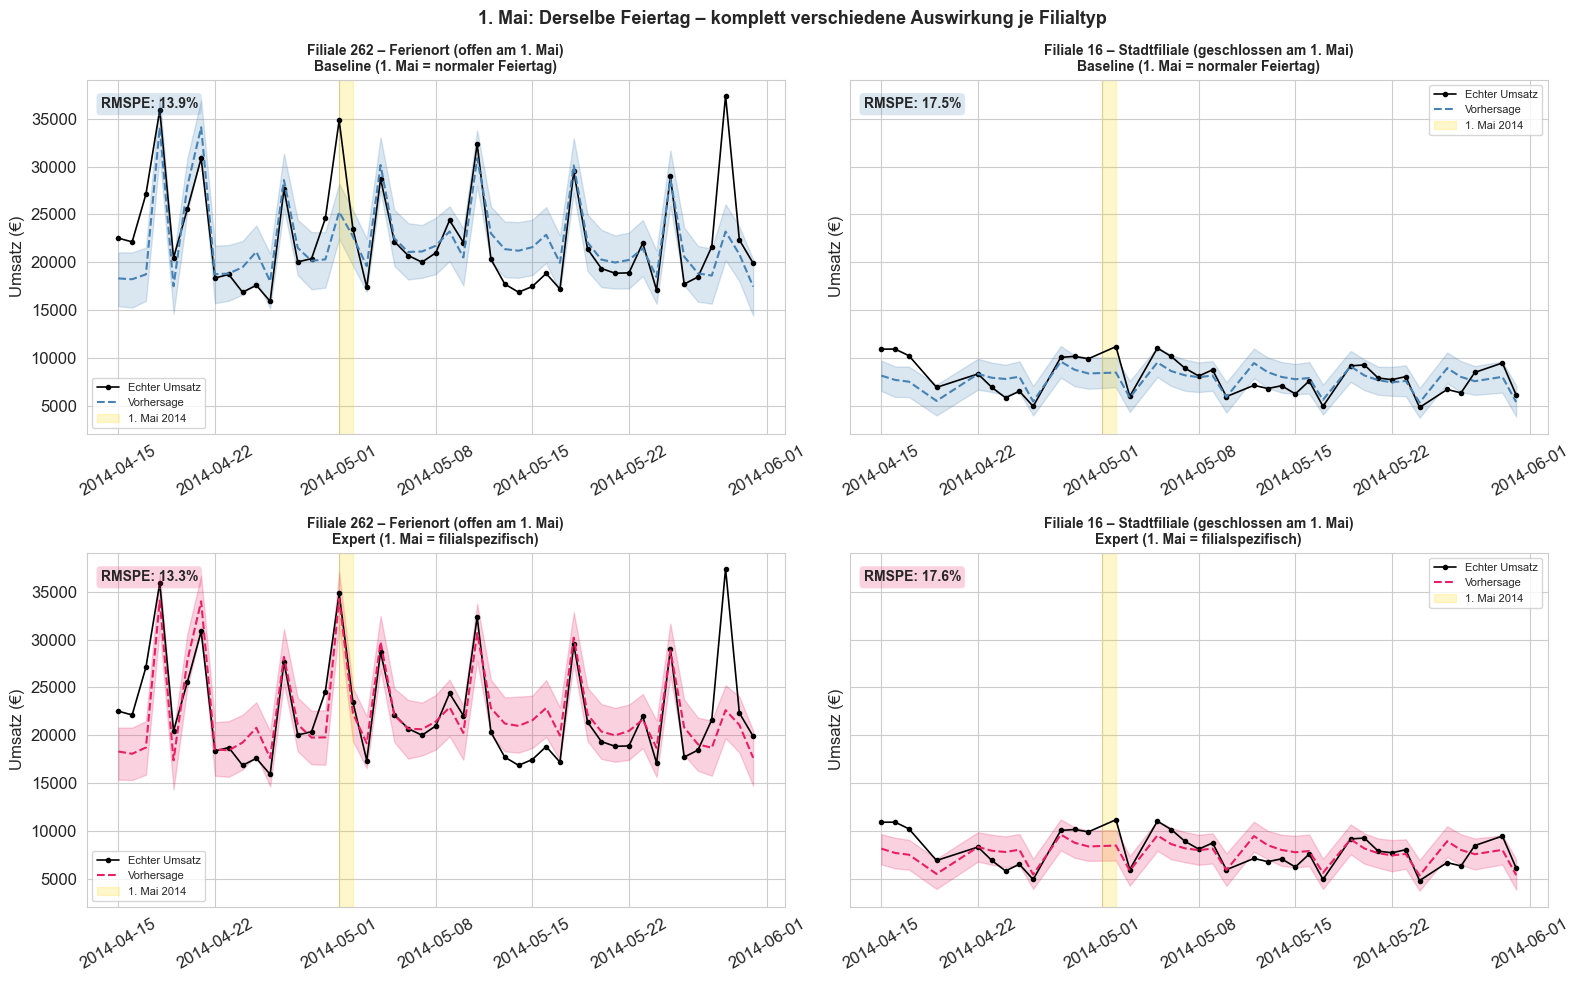

🎯 Key Message:
   Filiale 262 (Ferienort): Expert lernt aus 2013 → Umsatz-Boom am 1. Mai
   Filiale 16  (Stadt):     Expert lernt aus 2013 → Schließung am 1. Mai
   Derselbe Holiday-Name, aber filialspezifischer Effekt – kein generisches Modell kann das!


In [18]:
# Vergleichsplot: Filiale 262 (Ferienort) vs. Filiale 16 (Stadt)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')

for col, (p_test, fc_base, fc_expert, store_id, store_label) in enumerate([
    (p_test_262, fc_base_262, fc_expert_262, 262, 'Filiale 262 – Ferienort (offen am 1. Mai)'),
    (p_test_16,  fc_base_16,  fc_expert_16,  16,  'Filiale 16 – Stadtfiliale (geschlossen am 1. Mai)'),
]):
    y_true = p_test['y'].values
    dates  = p_test['ds'].values

    for row, (fc, model_label, color) in enumerate([
        (fc_base,   'Baseline (1. Mai = normaler Feiertag)', 'steelblue'),
        (fc_expert, 'Expert (1. Mai = filialspezifisch)',    '#E91E63'),
    ]):
        ax = axes[row][col]
        ax.plot(dates, y_true, 'o-', color='black', markersize=3, label='Echter Umsatz', linewidth=1.2)
        ax.plot(fc['ds'], fc['yhat'], '--', color=color, linewidth=1.5, label='Vorhersage')
        ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], alpha=0.2, color=color)
        ax.axvspan(pd.Timestamp('2014-05-01'), pd.Timestamp('2014-05-02'),
                   alpha=0.2, color='gold', label='1. Mai 2014')
        ax.set_title(f'{store_label}\n{model_label}', fontweight='bold', fontsize=10)
        ax.set_ylabel('Umsatz (€)')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)

        rmspe_val = rmspe(y_true, fc['yhat'].values)
        ax.text(0.02, 0.95, f'RMSPE: {rmspe_val:.1f}%', transform=ax.transAxes,
                fontweight='bold', fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))

plt.suptitle('1. Mai: Derselbe Feiertag – komplett verschiedene Auswirkung je Filialtyp',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('🎯 Key Message:')
print('   Filiale 262 (Ferienort): Expert lernt aus 2013 → Umsatz-Boom am 1. Mai')
print('   Filiale 16  (Stadt):     Expert lernt aus 2013 → Schließung am 1. Mai')
print('   Derselbe Holiday-Name, aber filialspezifischer Effekt – kein generisches Modell kann das!')

---
### 🏝️ 3.5 Vertiefung: Filiale 262 ignoriert ALLE Frühjahrs-Feiertage

Der 1. Mai war kein Einzelfall. Schaut man sich Mai/Juni 2014 bei Filiale 262 genauer an, zeigt sich ein **systematisches Muster**: An jedem gesetzlichen Feiertag macht die Insel-Filiale Spitzenumsätze statt zu schließen.

| Datum 2014 | Feiertag | StateHoliday | Umsatz | Normal Ø ~20.000€ |
|---|---|---|---|---|
| 1. Mai | Tag der Arbeit | `a` | ~34.000€ | **+70%** |
| 29. Mai | Christi Himmelfahrt | `a` | **37.403€** | **+85%** |
| 30. Mai | Brückentag | `0` ❗ | 22.340€ | +12% |
| 9. Juni | Pfingstmontag | `a` | 34.692€ | **+72%** |
| Sonntage | (geöffnet!) | `0` | ~30.000€ | **+50%** |

Während eine normale Filiale an diesen Tagen geschlossen ist (`StateHoliday='a'` → Einbruch), dreht Filiale 262 voll auf – Touristen haben am Feiertag Zeit zum Einkaufen. Wir bauen jetzt **alle** diese Insel-Feiertage als positiven Effekt ein.

In [19]:
# Testfenster bis Mitte Juni erweitern, damit Himmelfahrt + Pfingsten enthalten sind
STORE_262 = 262
CUTOFF_262   = '2014-04-15'
TEST_END_262 = '2014-06-15'

df_262 = train[train['Store'] == STORE_262].copy().sort_values('Date').reset_index(drop=True)
df_train_262 = df_262[(df_262['Date'] < CUTOFF_262) & (df_262['Open'] == 1)]
df_test_262b = df_262[(df_262['Date'] >= CUTOFF_262) & (df_262['Date'] <= TEST_END_262) & (df_262['Open'] == 1)]

p_train_262 = df_train_262[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
p_test_262b = df_test_262b[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

print(f'Filiale {STORE_262}: Training {len(df_train_262)} Tage, Test {len(df_test_262b)} Tage')
print(f'Testfenster: {df_test_262b["Date"].min().date()} – {df_test_262b["Date"].max().date()}')

Filiale 262: Training 469 Tage, Test 62 Tage
Testfenster: 2014-04-15 – 2014-06-15


In [20]:
# 🎯 ANALYST-WISSEN: Alle Frühjahrs-Feiertage als Insel-Effekt (positiv!)
# Diese Tage sind im Datensatz als StateHoliday='a' (=Einbruch erwartet) kodiert,
# aber Filiale 262 macht hier ihre höchsten Umsätze.
feiertage_insel_262 = pd.DataFrame({
    'ds': pd.to_datetime([
        '2013-05-01', '2014-05-01',   # Tag der Arbeit
        '2013-05-09', '2014-05-29',   # Christi Himmelfahrt
        '2013-05-20', '2014-06-09',   # Pfingstmontag
    ]),
    'holiday': 'feiertag_insel'
})

# Brückentage (StateHoliday='0', aber erhöhter Umsatz)
brueckentage_262 = pd.DataFrame({
    'ds': pd.to_datetime(['2013-05-10', '2014-05-30']),  # Freitag nach Himmelfahrt
    'holiday': 'brueckentag'
})

# Baseline: alle gesetzlichen Feiertage als generischer Effekt (Einbruch)
holidays_262_baseline = pd.concat([feiertage_a, ostern_standard, weihnachten, schulferien],
                                  ignore_index=True)

# Expert: Frühjahrs-Feiertage aus generischem Set entfernen, als Insel-Effekt neu einbauen
insel_daten = feiertage_insel_262['ds'].tolist()
feiertage_a_ohne_insel = feiertage_a[~feiertage_a['ds'].isin(insel_daten)].copy()
holidays_262_expert = pd.concat([
    feiertage_a_ohne_insel, ostern_standard, weihnachten, schulferien,
    feiertage_insel_262, brueckentage_262
], ignore_index=True)

print('🎯 Expert-Modell für Filiale 262 kennt:')
print('   feiertag_insel → 1. Mai, Himmelfahrt, Pfingstmontag als POSITIVE Effekte')
print('   brueckentag    → Freitag nach Himmelfahrt (StateHoliday=0!)')

🎯 Expert-Modell für Filiale 262 kennt:
   feiertag_insel → 1. Mai, Himmelfahrt, Pfingstmontag als POSITIVE Effekte
   brueckentag    → Freitag nach Himmelfahrt (StateHoliday=0!)


In [21]:
# Baseline vs. Expert für Filiale 262
m_base_262 = Prophet(holidays=holidays_262_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_base_262.fit(p_train_262)
fc_base_262b = m_base_262.predict(p_test_262b[['ds']])

m_expert_262 = Prophet(holidays=holidays_262_expert, yearly_seasonality=True,
                       weekly_seasonality=True, interval_width=0.80)
m_expert_262.fit(p_train_262)
fc_expert_262b = m_expert_262.predict(p_test_262b[['ds']])
print('✅ Beide Modelle trainiert!')

21:05:00 - cmdstanpy - INFO - Chain [1] start processing
21:05:01 - cmdstanpy - INFO - Chain [1] done processing
21:05:01 - cmdstanpy - INFO - Chain [1] start processing
21:05:01 - cmdstanpy - INFO - Chain [1] done processing


✅ Beide Modelle trainiert!


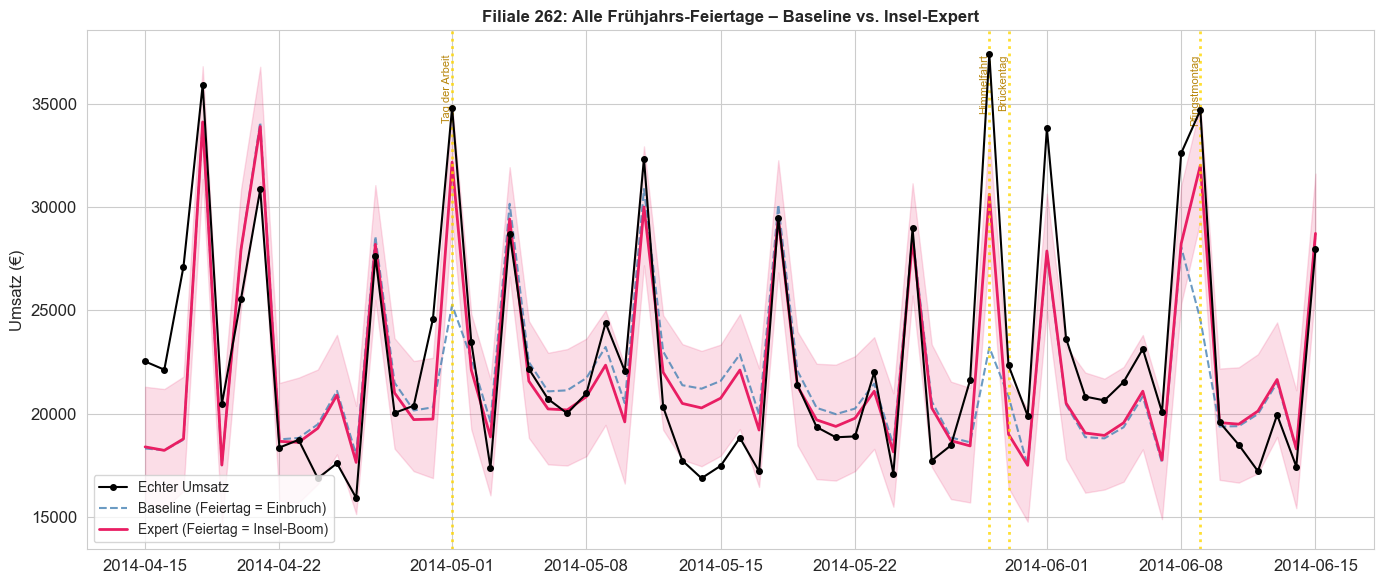

Modellvergleich Filiale 262 (Frühjahrs-Feiertage):
Baseline:
  RMSE:  3599 €
  RMSPE: 13.7%
Expert  :
  RMSE:  2654 €
  RMSPE: 11.2%

🏝️ Die Baseline bricht an jedem Feiertag ein – Expert kennt das Insel-Muster!


In [22]:
# Vergleichsplot mit allen Frühjahrs-Feiertagen markiert
y_true_262b    = p_test_262b['y'].values
test_dates_262b = p_test_262b['ds'].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates_262b, y_true_262b, 'o-', color='black', markersize=4,
        label='Echter Umsatz', linewidth=1.5, zorder=5)
ax.plot(fc_base_262b['ds'], fc_base_262b['yhat'], '--', color='steelblue',
        linewidth=1.5, label='Baseline (Feiertag = Einbruch)', alpha=0.8)
ax.plot(fc_expert_262b['ds'], fc_expert_262b['yhat'], '-', color='#E91E63',
        linewidth=2, label='Expert (Feiertag = Insel-Boom)')
ax.fill_between(fc_expert_262b['ds'], fc_expert_262b['yhat_lower'], fc_expert_262b['yhat_upper'],
                alpha=0.15, color='#E91E63')

# Alle Frühjahrs-Feiertage markieren
feiertage_marker = {
    '2014-05-01': 'Tag der Arbeit',
    '2014-05-29': 'Himmelfahrt',
    '2014-05-30': 'Brückentag',
    '2014-06-09': 'Pfingstmontag',
}
for datum, name in feiertage_marker.items():
    ax.axvline(pd.Timestamp(datum), color='gold', linestyle=':', linewidth=2, alpha=0.8)
    ax.text(pd.Timestamp(datum), ax.get_ylim()[1]*0.97, name, rotation=90,
            fontsize=8, va='top', ha='right', color='darkgoldenrod')

ax.set_title(f'Filiale {STORE_262}: Alle Frühjahrs-Feiertage – Baseline vs. Insel-Expert',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Umsatz (€)')
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.show()

print('Modellvergleich Filiale 262 (Frühjahrs-Feiertage):')
print_metrics(y_true_262b, fc_base_262b['yhat'].values,   'Baseline')
print_metrics(y_true_262b, fc_expert_262b['yhat'].values, 'Expert  ')
print()
print('🏝️ Die Baseline bricht an jedem Feiertag ein – Expert kennt das Insel-Muster!')

---
## 🏷️ 4. Promo-Effekte: Holiday vs. Regressor

Bisher haben wir Domänenwissen nur über **Holidays** ($h(t)$) eingebaut. Für Promotionen gibt es einen besseren Weg: den **Regressor**.

### 🧮 Jetzt erweitern wir die Gleichung

Bisher kamen wir mit der Grundform aus:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Für externe, steuerbare Einflussgrößen ergänzen wir nun den **Regressor-Term** $\beta X(t)$:

$$y(t) = g(t) + s(t) + h(t) + \boldsymbol{\beta X(t)} + \epsilon_t$$

* **$X(t)$:** eine externe Variable – hier: *Läuft an Tag $t$ eine Promo?* (0/1)
* **$\beta$:** der gelernte Effekt-Koeffizient, konstant über die gesamte Zeitreihe

### Holiday vs. Regressor – was ist der Unterschied?

| | Holiday | Regressor (`add_regressor`) |
|---|---|---|
| Wertebereich | nur 0/1 (Tag ist Event oder nicht) | beliebig (auch kontinuierlich) |
| Zukunft | aus Kalender ableitbar | **muss selbst geliefert werden** |
| Modus | additiv oder multiplikativ | additiv oder multiplikativ |
| Typischer Einsatz | Feiertage, Events | Promo, Preis, Wetter |

Bei Rossmann ist `Promo` bereits als 0/1-Spalte im Datensatz – auch für den Testzeitraum. Wir können sie also direkt als Regressor nutzen, ohne sie schätzen zu müssen.

### Filiale 198 – der Promo-Junkie

Filiale 198 reagiert extrem stark auf Promotionen: **+145% Umsatz** an Promo-Tagen. Ideal um den Effekt sichtbar zu machen.

Wir vergleichen drei Modelle:
1. **Baseline** – nur Feiertage, kein Promo-Wissen
2. **Promo als Holiday** – jeder Promo-Tag als Event
3. **Promo als Regressor** – `add_regressor('promo')`

Filiale 198:
  Training: 682 Tage (307 mit Promo)
  Test:     47 Tage (21 mit Promo)


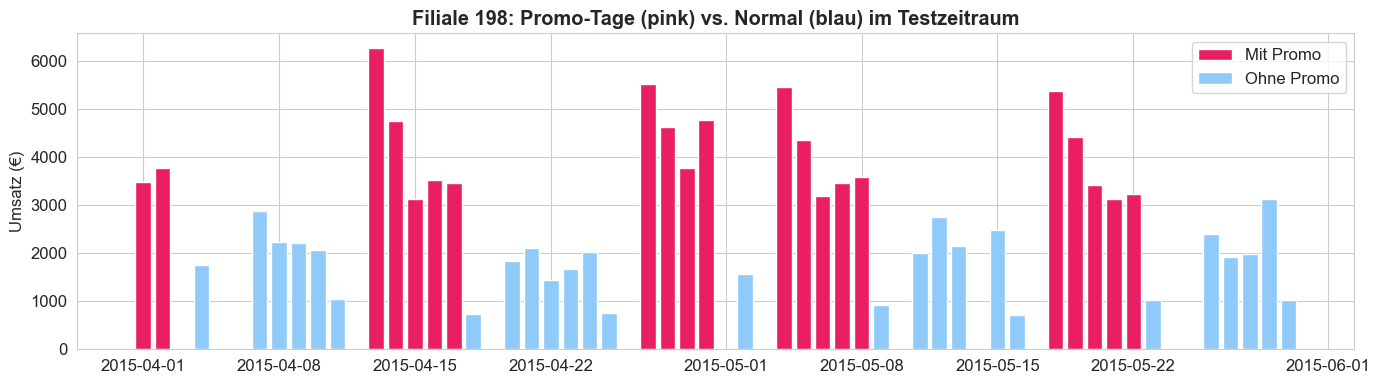

💡 Der Promo-Effekt ist riesig – an Promo-Tagen oft das Doppelte oder mehr!


In [23]:
STORE_PROMO    = 198
CUTOFF_PROMO   = '2015-04-01'
TEST_END_PROMO = '2015-05-31'

df_198 = train[train['Store'] == STORE_PROMO].copy().sort_values('Date').reset_index(drop=True)

df_train_198 = df_198[(df_198['Date'] < CUTOFF_PROMO) & (df_198['Open'] == 1)]
df_test_198  = df_198[(df_198['Date'] >= CUTOFF_PROMO) & (df_198['Date'] <= TEST_END_PROMO) & (df_198['Open'] == 1)]

print(f'Filiale {STORE_PROMO}:')
print(f'  Training: {len(df_train_198)} Tage ({(df_train_198["Promo"]==1).sum()} mit Promo)')
print(f'  Test:     {len(df_test_198)} Tage ({(df_test_198["Promo"]==1).sum()} mit Promo)')

# Promo-Muster im Test zeigen
fig, ax = plt.subplots(figsize=(14, 4))
promo_tage    = df_test_198[df_test_198['Promo'] == 1]
kein_promo    = df_test_198[df_test_198['Promo'] == 0]
ax.bar(promo_tage['Date'], promo_tage['Sales'], color='#E91E63', label='Mit Promo', width=0.8)
ax.bar(kein_promo['Date'], kein_promo['Sales'], color='#90CAF9', label='Ohne Promo', width=0.8)
ax.set_title(f'Filiale {STORE_PROMO}: Promo-Tage (pink) vs. Normal (blau) im Testzeitraum', fontweight='bold')
ax.set_ylabel('Umsatz (€)')
ax.legend()
plt.tight_layout()
plt.show()
print('💡 Der Promo-Effekt ist riesig – an Promo-Tagen oft das Doppelte oder mehr!')

In [24]:
# === Modell 1: Baseline (nur Feiertage) ===
p_train_198 = df_train_198[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
p_test_198  = df_test_198[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

m_base_198 = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                     weekly_seasonality=True, interval_width=0.80)
m_base_198.fit(p_train_198)
fc_base_198 = m_base_198.predict(p_test_198[['ds']])
print('✅ Modell 1 (Baseline) fertig')

21:05:14 - cmdstanpy - INFO - Chain [1] start processing
21:05:14 - cmdstanpy - INFO - Chain [1] done processing


✅ Modell 1 (Baseline) fertig


In [25]:
# === Modell 2: Promo als HOLIDAY ===
# Jeder Promo-Tag wird als Event behandelt
promo_holidays = df_198[df_198['Promo'] == 1][['Date']].rename(columns={'Date': 'ds'})
promo_holidays['holiday'] = 'promo'
holidays_mit_promo = pd.concat([holidays_baseline, promo_holidays], ignore_index=True)

m_holiday_198 = Prophet(holidays=holidays_mit_promo, yearly_seasonality=True,
                        weekly_seasonality=True, interval_width=0.80)
m_holiday_198.fit(p_train_198)
fc_holiday_198 = m_holiday_198.predict(p_test_198[['ds']])
print('✅ Modell 2 (Promo als Holiday) fertig')

21:05:15 - cmdstanpy - INFO - Chain [1] start processing
21:05:15 - cmdstanpy - INFO - Chain [1] done processing


✅ Modell 2 (Promo als Holiday) fertig


In [26]:
# === Modell 3: Promo als REGRESSOR ===
# Die 'promo'-Spalte muss in Training UND Test vorhanden sein
p_train_reg = df_train_198[['Date', 'Sales', 'Promo']].rename(
    columns={'Date': 'ds', 'Sales': 'y', 'Promo': 'promo'})
p_test_reg  = df_test_198[['Date', 'Promo']].rename(
    columns={'Date': 'ds', 'Promo': 'promo'})

m_reg_198 = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                    weekly_seasonality=True, interval_width=0.80)
# 🎯 Der entscheidende Schritt: Promo als Regressor anmelden
# mode='multiplicative', weil Promo den Umsatz prozentual anhebt (+145%!)
m_reg_198.add_regressor('promo', mode='multiplicative')
m_reg_198.fit(p_train_reg)
fc_reg_198 = m_reg_198.predict(p_test_reg)
print('✅ Modell 3 (Promo als Regressor) fertig')

21:05:17 - cmdstanpy - INFO - Chain [1] start processing
21:05:17 - cmdstanpy - INFO - Chain [1] done processing


✅ Modell 3 (Promo als Regressor) fertig


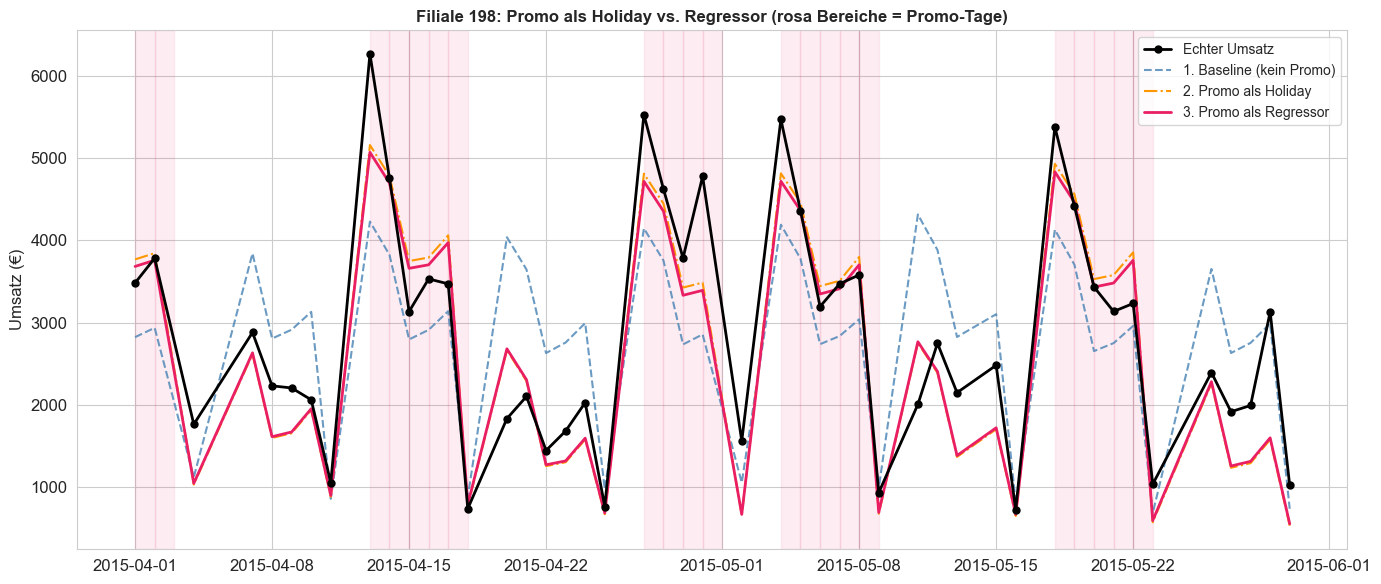

Modellvergleich Filiale 198:
1. Baseline       :
  RMSE:  977 €
  RMSPE: 40.2%
2. Promo=Holiday  :
  RMSE:  564 €
  RMSPE: 24.2%
3. Promo=Regressor:
  RMSE:  565 €
  RMSPE: 23.6%


In [27]:
# Vergleich aller drei Modelle
y_true_198    = p_test_198['y'].values
test_dates_198 = p_test_198['ds'].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates_198, y_true_198, 'o-', color='black', markersize=5,
        label='Echter Umsatz', linewidth=2, zorder=5)
ax.plot(fc_base_198['ds'], fc_base_198['yhat'], '--', color='steelblue',
        linewidth=1.5, label='1. Baseline (kein Promo)', alpha=0.8)
ax.plot(fc_holiday_198['ds'], fc_holiday_198['yhat'], '-.', color='#FF9800',
        linewidth=1.5, label='2. Promo als Holiday')
ax.plot(fc_reg_198['ds'], fc_reg_198['yhat'], '-', color='#E91E63',
        linewidth=2, label='3. Promo als Regressor')

# Promo-Tage im Hintergrund markieren
for d in df_test_198[df_test_198['Promo'] == 1]['Date']:
    ax.axvspan(d, d + pd.Timedelta(days=1), alpha=0.08, color='#E91E63')

ax.set_title(f'Filiale {STORE_PROMO}: Promo als Holiday vs. Regressor (rosa Bereiche = Promo-Tage)',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Umsatz (€)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Modellvergleich Filiale 198:')
print_metrics(y_true_198, fc_base_198['yhat'].values,    '1. Baseline       ')
print_metrics(y_true_198, fc_holiday_198['yhat'].values, '2. Promo=Holiday  ')
print_metrics(y_true_198, fc_reg_198['yhat'].values,     '3. Promo=Regressor')

### 💡 Warum Regressor oft besser ist als Holiday

Beide Ansätze können den Promo-Effekt abbilden, aber:

- **Holiday** behandelt jeden Promo-Tag als isoliertes Event. Bei sehr vielen Promo-Tagen wird das Modell unübersichtlich und überschätzt evtl. einzelne Tage.
- **Regressor** lernt **einen** Promo-Koeffizienten aus allen Daten und wendet ihn konsistent an. Das ist robuster, besser interpretierbar (\"Promo = +X%\") und der natürliche Weg für wiederkehrende, planbare Einflüsse.

Faustregel: **Einmalige Kalender-Events → Holiday. Wiederkehrende, steuerbare Einflüsse (Promo, Preis) → Regressor.**

---
## 📏 5. Gesamtvergleich & Fazit

### Was haben wir gelernt?

| Effekt | Im Datensatz | Prophet Baseline | Prophet Expert |
|---|---|---|---|
| Ostersamstag (530) | `StateHoliday=0` | ❌ normaler Samstag | ✅ Boom-Tag |
| Ostermontag (530) | `StateHoliday=b` | ❌ Schließung | ✅ geöffnet |
| 1. Mai Ferienort (262) | `StateHoliday=a` | ❌ Einbruch | ✅ Boom |
| Himmelfahrt/Pfingsten (262) | `StateHoliday=a` | ❌ Einbruch | ✅ Boom |
| Brückentag (262) | `StateHoliday=0` | ❌ normaler Tag | ✅ erhöht |
| 1. Mai Stadtfiliale (16) | `StateHoliday=a` | ✅ Einbruch | ✅ Einbruch |
| Promo (198) | `Promo=1` | ❌ ignoriert | ✅ als Regressor (+145%) |

### 🔑 Key Takeaways

1. **Derselbe Feiertag kann je nach Filialtyp einen komplett entgegengesetzten Effekt haben** – ein generisches Modell kann das nicht unterscheiden.
2. **Manche Effekte sind im Datensatz unsichtbar** (Ostersamstag = `StateHoliday=0`) – nur der Analyst erkennt sie.
3. **Holidays für Events, Regressoren für steuerbare Einflüsse** – Promo, Preis und Wetter gehören als `add_regressor` ins Modell, nicht als Holiday.
4. Der **Analyst-in-the-Loop** ist kein Nice-to-have – bei Insel-, Ferienort-Filialen und Promo-getriebenen Filialen ist er unverzichtbar.

### 🚀 Mögliche nächste Schritte
- Mehrere Regressoren kombinieren (Promo + Promo2 + CompetitionDistance)
- Cross-Validation mit Prophet (`cross_validation()`) für robustere Metriken
- Mehrere Filialen gleichzeitig mit hierarchischen Modellen vorhersagen

---
## 🦢 6. Der Strukturbruch: Wenn Saisonalität auf die Realität prallt

**Das Szenario:** Wir haben fantastische, saubere Flugdaten für das gesamte Jahr 2019 bis Ende Februar 2020. Wir können wöchentliche Muster und Feiertags-Peaks perfekt ablesen. Wir stehen am **1. März 2020** und sollen den Frühling prognostizieren. 

**Das Problem:** Klassische Modelle wie Prophet sind hervorragend darin, die Vergangenheit zu lernen und Saisonalitäten fortzuschreiben. Aber sie haben keine "Sensoren" für externe Schocks. Schauen wir uns an, was passiert, wenn ein Modell, das auf eine normale Welt trainiert wurde, auf die COVID-19-Pandemie trifft.

The last date in the dataset is: 2022-05-31


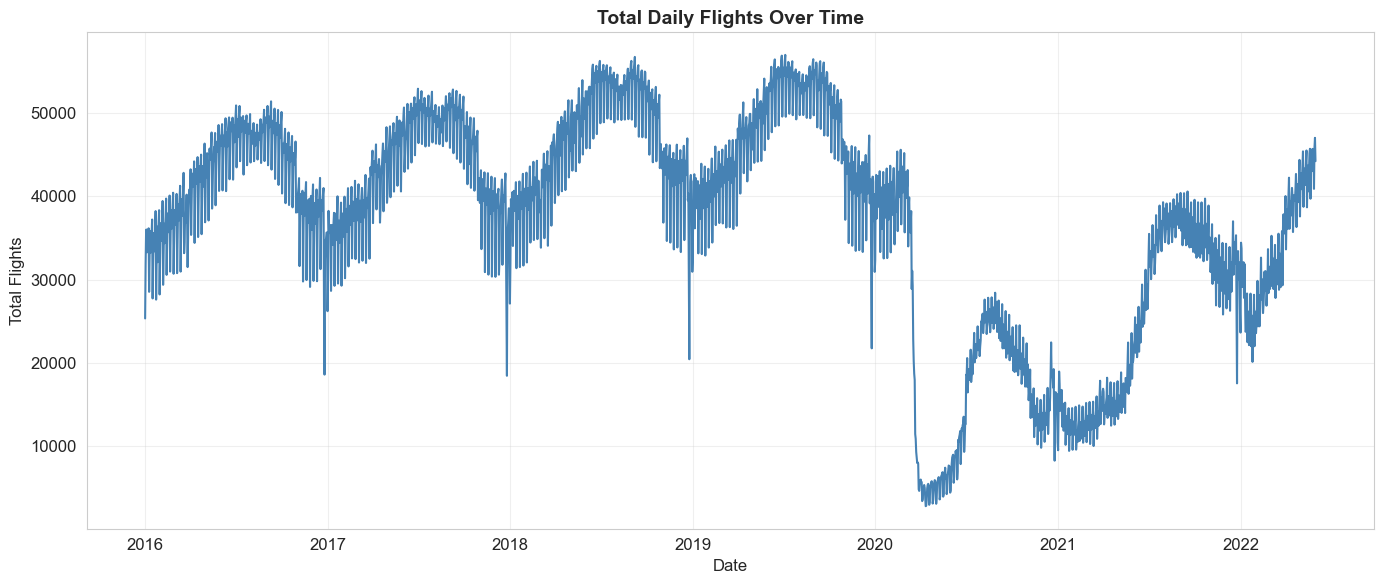

In [34]:
# Flugdaten laden und ersten Überblick verschaffen
# FLT_TOT_1 = Gesamte Flugbewegungen (Starts + Landungen) pro Flughafen und Tag
df = pd.read_csv('../data/flights.csv', parse_dates=['FLT_DATE'])

print(f"Spalten: {list(df.columns)}")
print(f"Zeitraum: {df['FLT_DATE'].min().date()} – {df['FLT_DATE'].max().date()}")
print(f"Einträge: {len(df):,}  |  Flughäfen: {df['APT_ICAO'].nunique()}")

# Alle Flughäfen pro Tag summieren für den Gesamtüberblick
daily_eda = df.groupby('FLT_DATE')['FLT_TOT_1'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_eda['FLT_DATE'], daily_eda['FLT_TOT_1'], color='steelblue', linewidth=1.5)
ax.set_title('Tägliche Flugbewegungen in Europa (alle Flughäfen, summiert)', fontweight='bold', fontsize=14)
ax.set_xlabel('Datum')
ax.set_ylabel('Flugbewegungen pro Tag (FLT_TOT_1)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### ✈️ 6.1 Prophet im Stresstest: Saisonalität vs. "Black Swan"

Wir nutzen nun echte europäische Flugbewegungsdaten, um Prophet einem finalen Test zu unterziehen. Wir teilen das Experiment in zwei Phasen auf:

1. **Die "heile Welt" (2016-2018):** Wir trainieren Prophet auf 2016 und 2017 und lassen das Modell das Jahr 2018 vorhersagen. Hier erwarten wir, dass Prophet glänzt.
2. **Der Black Swan (2018-2020):** Wir trainieren Prophet auf 2018 und 2019 und prognostizieren das Jahr 2020. Hier trifft mathematisches Curve-Fitting auf den globalen COVID-19-Lockdown.

In [37]:
# Flugdaten für Prophet aufbereiten (df wurde oben geladen)
# Alle Flughäfen pro Tag summieren und in Prophet-Format bringen
daily_flights = df.groupby('FLT_DATE')['FLT_TOT_1'].sum().reset_index()
daily_flights = daily_flights.rename(columns={'FLT_DATE': 'ds', 'FLT_TOT_1': 'y'})

# Zeitzonen-Infos entfernen (Prophet erwartet timezone-naive Datumsangaben)
if daily_flights['ds'].dt.tz is not None:
    daily_flights['ds'] = daily_flights['ds'].dt.tz_localize(None)

print(f"✅ Daten aufbereitet: {len(daily_flights)} Tage ({daily_flights['ds'].min().date()} – {daily_flights['ds'].max().date()})")

Lade Flugdaten...
✅ Daten erfolgreich aufbereitet!


In [40]:
# --- PHASE 1: Vorhersage 2018 (Trainiert auf 2016-2017) ---
print("Trainiere Modell 1: Normales Jahr (2018)...")

# Datensplits
train_2016_2017 = daily_flights[(daily_flights['ds'].dt.year >= 2016) & (daily_flights['ds'].dt.year <= 2017)]
test_2018 = daily_flights[daily_flights['ds'].dt.year == 2018]

# Prophet trainieren
m_normal = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_normal.fit(train_2016_2017)
fc_2018 = m_normal.predict(test_2018[['ds']])

print("✅ Vorhersage für 2018 abgeschlossen!")

21:07:09 - cmdstanpy - INFO - Chain [1] start processing
21:07:09 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Modell 1: Normales Jahr (2018)...
✅ Vorhersage für 2018 abgeschlossen!


In [41]:
# --- PHASE 2: Vorhersage 2020 (Trainiert auf 2018-2019) ---
print("Trainiere Modell 2: Krisenjahr (2020)...")

# Datensplits
train_2018_2019 = daily_flights[(daily_flights['ds'].dt.year >= 2018) & (daily_flights['ds'].dt.year <= 2019)]
test_2020 = daily_flights[daily_flights['ds'].dt.year == 2020]

# Prophet trainieren
m_covid = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m_covid.fit(train_2018_2019)
fc_2020 = m_covid.predict(test_2020[['ds']])

print("✅ Vorhersage für 2020 abgeschlossen!")

21:07:10 - cmdstanpy - INFO - Chain [1] start processing
21:07:11 - cmdstanpy - INFO - Chain [1] done processing


Trainiere Modell 2: Krisenjahr (2020)...
✅ Vorhersage für 2020 abgeschlossen!


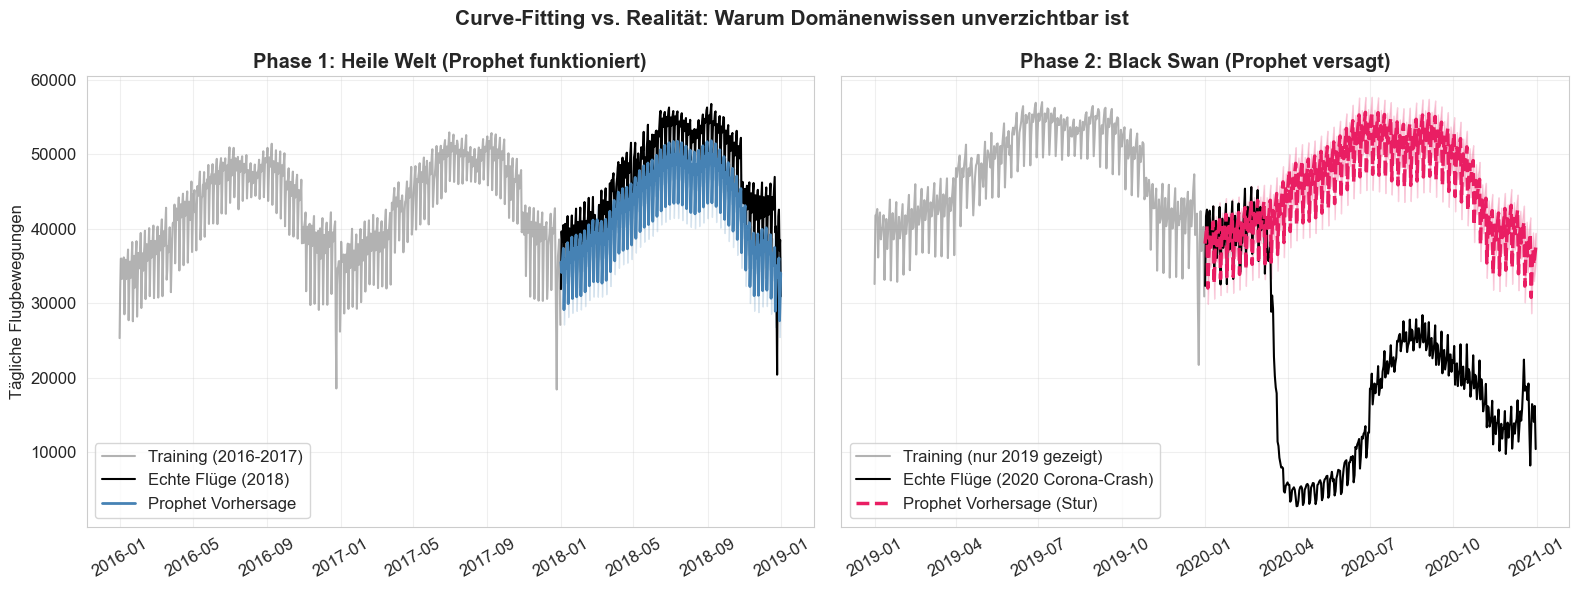

In [42]:
# Visualisierung: Der große Vergleich
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# ---------------------------------------------------------
# Plot 1: Der Erfolg (2018)
# ---------------------------------------------------------
axes[0].plot(train_2016_2017['ds'], train_2016_2017['y'], color='gray', alpha=0.6, label='Training (2016-2017)')
axes[0].plot(test_2018['ds'], test_2018['y'], color='black', markersize=3, label='Echte Flüge (2018)')
axes[0].plot(fc_2018['ds'], fc_2018['yhat'], color='steelblue', linewidth=2, label='Prophet Vorhersage')
axes[0].fill_between(fc_2018['ds'], fc_2018['yhat_lower'], fc_2018['yhat_upper'], alpha=0.2, color='steelblue')

axes[0].set_title('Phase 1: Heile Welt (Prophet funktioniert)', fontweight='bold')
axes[0].set_ylabel('Tägliche Flugbewegungen')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------------
# Plot 2: Das Scheitern (2020)
# ---------------------------------------------------------
# Wir zoomen hier etwas rein (nur 2019 im Training anzeigen), damit der Absturz dramatischer wirkt
train_2019_only = train_2018_2019[train_2018_2019['ds'].dt.year == 2019]

axes[1].plot(train_2019_only['ds'], train_2019_only['y'], color='gray', alpha=0.6, label='Training (nur 2019 gezeigt)')
axes[1].plot(test_2020['ds'], test_2020['y'], color='black', markersize=3, label='Echte Flüge (2020 Corona-Crash)')
axes[1].plot(fc_2020['ds'], fc_2020['yhat'], color='#E91E63', linestyle='--', linewidth=2.5, label='Prophet Vorhersage (Stur)')
axes[1].fill_between(fc_2020['ds'], fc_2020['yhat_lower'], fc_2020['yhat_upper'], alpha=0.2, color='#E91E63')

axes[1].set_title('Phase 2: Black Swan (Prophet versagt)', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curve-Fitting vs. Realität: Warum Domänenwissen unverzichtbar ist', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Metriken im Vergleich: normales Jahr vs. Strukturbruch
print("📊 Modellgüte: Normales Jahr 2018 vs. Corona-Krisenjahr 2020")
print("-" * 60)

y_2018 = test_2018['y'].values
y_2020 = test_2020['y'].values
yhat_2018 = fc_2018['yhat'].values
yhat_2020 = fc_2020['yhat'].values

# MAPE nur für Tage mit tatsächlichen Flügen berechnen
mask_2018 = y_2018 > 0
mask_2020 = y_2020 > 0

mape_2018 = np.mean(np.abs((y_2018[mask_2018] - yhat_2018[mask_2018]) / y_2018[mask_2018])) * 100
mape_2020 = np.mean(np.abs((y_2020[mask_2020] - yhat_2020[mask_2020]) / y_2020[mask_2020])) * 100
rmse_2018 = rmse(y_2018, yhat_2018)
rmse_2020 = rmse(y_2020, yhat_2020)

print(f"2018 (normales Jahr):      MAPE = {mape_2018:5.1f}%   RMSE = {rmse_2018:,.0f} Flüge/Tag")
print(f"2020 (Corona-Krisenjahr):  MAPE = {mape_2020:5.1f}%   RMSE = {rmse_2020:,.0f} Flüge/Tag")
print()
print(f"🚨 MAPE steigt von {mape_2018:.0f}% auf {mape_2020:.0f}% – Faktor {mape_2020/mape_2018:.0f}x!")
print("   Ein Black Swan macht alle historisch gelernten Muster wertlos.")
print("   Kein Modell kann einen nie dagewesenen Einbruch korrekt vorhersagen.")

---
## 📈 7. Wenn eine Filiale wächst: Trend-Analyse im Rossmann-Datensatz

Prophet trennt automatisch den **Trend** $g(t)$ von Saisonalität und Feiertagen.
Bisher war der Trend in unseren Beispielen relativ stabil. Manche Filialen zeigen
jedoch tatsächlich ein kontinuierliches Wachstum – Prophet's Trend-Komponente macht
dieses Wachstum sichtbar und extrapoliert es in die Zukunft.

Wir suchen zunächst systematisch die Rossmann-Filiale mit dem stärksten linearen Wachstum.

In [ ]:
from sklearn.linear_model import LinearRegression

# Alle Filialen auf linearen Trend untersuchen (Basis: Monatsdurchschnitt)
stores_trend = []
for store_id in train['Store'].unique():
    df_s = train[(train['Store'] == store_id) & (train['Open'] == 1)].copy()
    df_monthly = df_s.groupby(df_s['Date'].dt.to_period('M'))['Sales'].mean()
    if len(df_monthly) < 20:
        continue
    X = np.arange(len(df_monthly)).reshape(-1, 1)
    y_vals = df_monthly.values
    lr = LinearRegression().fit(X, y_vals)
    stores_trend.append({
        'Store': int(store_id),
        'Slope (€/Monat)': round(lr.coef_[0], 1),
        'R²': round(lr.score(X, y_vals), 3)
    })

trend_df = pd.DataFrame(stores_trend).sort_values('Slope (€/Monat)', ascending=False)
print("Top 5 Filialen mit stärkstem positivem Wachstumstrend:")
print(trend_df.head(5).to_string(index=False))
print("\nTop 5 Filialen mit stärkstem negativem Trend (Rückgang):")
print(trend_df.tail(5).to_string(index=False))

TREND_STORE = int(trend_df.iloc[0]['Store'])
print(f"\n→ Prophet-Modell für Filiale {TREND_STORE} (stärkster Aufwärtstrend).")

In [ ]:
# Filiale mit stärkstem Wachstum: Daten vorbereiten und visualisieren
CUTOFF_TREND   = '2015-01-01'
TEST_END_TREND = '2015-07-31'

df_trend = train[(train['Store'] == TREND_STORE) & (train['Open'] == 1)].copy().sort_values('Date')
df_train_trend = df_trend[df_trend['Date'] < CUTOFF_TREND]
df_test_trend  = df_trend[(df_trend['Date'] >= CUTOFF_TREND) & (df_trend['Date'] <= TEST_END_TREND)]

p_train_trend = df_train_trend[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
p_test_trend  = df_test_trend[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

# Monatsdurchschnitt als Trendlinie
df_monthly_t = (
    df_trend.groupby(df_trend['Date'].dt.to_period('M'))['Sales']
    .mean().reset_index()
)
df_monthly_t['Date'] = df_monthly_t['Date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_trend['Date'], df_trend['Sales'], color='steelblue', alpha=0.3, linewidth=0.7, label='Tagesumsatz')
ax.plot(df_monthly_t['Date'], df_monthly_t['Sales'], color='black', linewidth=2.5, label='Monatsdurchschnitt')
ax.axvline(pd.Timestamp(CUTOFF_TREND), color='red', linestyle='--', linewidth=1.5, label='Train/Test-Grenze')
ax.set_title(f'Filiale {TREND_STORE}: Tagesumsatz mit sichtbarem Wachstumstrend', fontweight='bold')
ax.set_ylabel('Umsatz (€)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Training: {len(df_train_trend)} Tage | Test: {len(df_test_trend)} Tage')

In [ ]:
# Prophet modellieren – Trend-Komponente im Fokus
m_trend = Prophet(holidays=holidays_baseline, yearly_seasonality=True,
                  weekly_seasonality=True, interval_width=0.80)
m_trend.fit(p_train_trend)
fc_trend = m_trend.predict(p_test_trend[['ds']])

# Vorhersage vs. Realität
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(p_test_trend['ds'], p_test_trend['y'], 'o-', color='black', markersize=3,
        label='Echter Umsatz', linewidth=1.5)
ax.plot(fc_trend['ds'], fc_trend['yhat'], '--', color='#E91E63', linewidth=2, label='Prophet Vorhersage')
ax.fill_between(fc_trend['ds'], fc_trend['yhat_lower'], fc_trend['yhat_upper'], alpha=0.2, color='#E91E63')
ax.set_title(f'Filiale {TREND_STORE}: Prophet extrapoliert den Wachstumstrend', fontweight='bold')
ax.set_ylabel('Umsatz (€)')
ax.legend()
plt.tight_layout()
plt.show()

# Trend-Komponente sichtbar machen
future_trend = m_trend.make_future_dataframe(periods=60)
fc_full_trend = m_trend.predict(future_trend)
fig = m_trend.plot_components(fc_full_trend)
fig.suptitle(f'Prophet Komponenten – Filiale {TREND_STORE} (Trend + Saisonalität)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print_metrics(p_test_trend['y'].values, fc_trend['yhat'].values, f'Prophet Trend-Modell (Filiale {TREND_STORE})')
print(f'\n💡 Im Trend-Plot (oben links): Prophet hat den linearen Aufwärtstrend erfasst')
print('   und extrapoliert ihn korrekt in den Test-Zeitraum.')

---
## 🔄 8. Modellvalidierung: Wie robust ist unsere Prognose?

Ein einzelner Train-Test-Split (wie in allen bisherigen Beispielen) hängt stark
vom gewählten Schnittdatum ab. Prophet's eingebaute **Cross-Validation**
simuliert viele solche Schnitte automatisch:

1. Trainiert auf einem wachsenden Trainings-Fenster (initial)
2. Bewertet die Vorhersagen für einen definierten Horizont (horizon)
3. Wiederholt dies alle period Tage

Das Ergebnis: Ein realistischeres Bild der Modellgüte – unabhängig von einem einzelnen Datum.

In [ ]:
from prophet.diagnostics import cross_validate, performance_metrics
from prophet.plot import plot_cross_validation_metric

# Cross-Validation für das Expert-Modell (Filiale 530)
# initial: Mindest-Trainingsgröße (730 Tage ≈ 2 Jahre Historik)
# period:  Abstand zwischen den simulierten Schnittdaten (90 Tage)
# horizon: Vorhersagehorizont, der bewertet wird (45 Tage voraus)
print("Starte Cross-Validation für Filiale 530 (Expert-Modell)...")
print("(mehrere simulierte Train-Test-Schnitte – kann einige Sekunden dauern)")

df_cv = cross_validate(
    m_expert_530,
    initial='730 days',
    period='90 days',
    horizon='45 days',
    parallel='processes'
)

df_perf = performance_metrics(df_cv)
print("\n📊 Performance-Metriken über den Vorhersagehorizont (Filiale 530, Expert-Modell):")
print(df_perf[['horizon', 'rmse', 'mae', 'mape', 'coverage']].to_string(index=False))

In [ ]:
# Visualisierung: Fehler über den Vorhersagehorizont
fig = plot_cross_validation_metric(df_cv, metric='mape')
plt.suptitle('Cross-Validation: MAPE über den Vorhersagehorizont (Filiale 530)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n💡 Je weiter der Horizont, desto größer der Fehler – das ist normal.")
print("   Coverage (Ziel ≈ 0.80 bei interval_width=0.80): Liegt der echte Wert")
print("   in ~80% der Fälle im Konfidenzintervall?")